# VisualBERT: A Simple and Performant Baseline for Vision and Language

# https://arxiv.org/pdf/1908.03557

**Authors:** Liunian Harold Li, Mark Yatskar, Da Yin, Cho-Jui Hsieh, Kai-Wei Chang
**Affiliations:** UCLA, Allen Institute for AI, Peking University
**Venue:** arXiv preprint, August 2019

---

## Abstract

VisualBERT is a simple and flexible framework for modeling vision-and-language tasks.
It extends BERT by introducing a set of visual embeddings derived from object region
proposals, allowing a single Transformer stack to jointly process image regions and
text tokens via self-attention. Pre-trained on COCO image caption data with two
visually-grounded objectives, VisualBERT achieves state-of-the-art or competitive
results on VQA, VCR, NLVR2, and Flickr30K, while being significantly simpler than
prior task-specific models.

---

## Problems

1. **Modality gap in existing models** — Prior vision-and-language models use separate,
   task-specific encoders for vision and language, with a fusion module bolted on top.
   This design prevents deep, early interaction between the two modalities and limits
   generalization across tasks.

2. **Lack of a universal cross-modal backbone** — Unlike language, where BERT provides
   a universal pre-trained encoder, no equivalent pre-trained joint vision-language
   backbone existed that could be adapted to arbitrary downstream tasks.

3. **Shallow or late cross-modal alignment** — Existing multi-modal fusion approaches
   typically combine modalities only at a final stage, preventing the model from learning
   fine-grained, layer-by-layer implicit alignments between words and image regions.

4. **No visually-grounded language model pre-training** — Prior work either pre-trained
   on language only (BERT) or on video with coarse visual tokens (VideoBERT), with no
   framework that pre-trained a shared Transformer on paired image-caption data using
   region-level visual features.

---

## Proposed Solutions

1. **Unified Transformer for vision and language** — A single BERT-style Transformer
   stack processes both text token embeddings and visual region embeddings jointly,
   enabling self-attention to discover implicit cross-modal alignments at every layer.

2. **Visual embeddings from object proposals** — Each image region $f \in F$ is
   represented as the sum of three embeddings:
   - $f_o$: a visual feature from a CNN over the bounding region
   - $f_s$: a segment embedding distinguishing image tokens from text tokens
   - $f_p$: an optional position embedding aligned to corresponding words

3. **Three-phase training procedure**:
   - Task-agnostic pre-training on COCO captions with two visually-grounded objectives
   - Task-specific pre-training on target task data using masked language modeling
   - Fine-tuning on the downstream task

4. **Two visually-grounded pre-training objectives**:
   - Masked language modeling with image context
   - Sentence-image prediction (matching vs. mismatched caption)

---

## Purpose

To establish a simple, general-purpose pre-trained backbone for vision-and-language
reasoning that:

1. Learns joint representations of image regions and language through shared
   self-attention, without modality-specific Transformer towers.
2. Requires minimal task-specific architectural modification for fine-tuning.
3. Demonstrates that implicit cross-modal grounding — including entity grounding
   and syntactic dependency alignment — emerges naturally from pre-training without
   any explicit supervision.

---

## Methodology

### 3.1 Input Representation

**Text embeddings** follow standard BERT: each subword token $w_i$ is embedded as:

$$e_i = e_t + e_s + e_p$$

where $e_t$ is the token embedding, $e_s$ the segment embedding, and $e_p$ the
positional embedding.

**Visual embeddings** for each detected region $f \in F$:

$$f = f_o + f_s + f_p$$

where $f_o$ is the CNN-extracted RoI feature, $f_s$ distinguishes the image segment
from the text segment, and $f_p$ (optional) encodes spatial or word-alignment position.

Both sets of embeddings are concatenated and passed jointly through the multi-layer
Transformer:

$$H = \text{Transformer}([e_1, \ldots, e_N, f_1, \ldots, f_K])$$

### 3.2 Pre-Training Objectives

**Objective 1 — Masked Language Modeling with Image:**

Some fraction of text tokens are replaced with $[\text{MASK}]$; the model predicts
the original tokens conditioned on remaining text and all image regions:

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}} \log P(w_i \mid w_{\backslash \mathcal{M}},\ F)$$

**Objective 2 — Sentence-Image Prediction:**

Given a text segment of two captions paired with an image, the model classifies whether
the second caption matches the image (50% chance of random replacement):

$$\mathcal{L}_{\text{SIP}} = -\log P(y \mid [\text{CLS}]\ \text{representation})$$

**Combined objective:**

$$\mathcal{L} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{SIP}}$$

### 3.3 Model Configuration

| Hyperparameter | Value |
|---|---|
| Transformer layers | 12 (same as $\text{BERT}_{\text{BASE}}$) |
| Hidden size | 768 |
| Self-attention heads | 12 |
| Parameter initialization | Pre-trained $\text{BERT}_{\text{BASE}}$ |
| Pre-training data | COCO (~100K images, 5 captions each) |
| Optimizer | Adam with linear warm-up (10% of steps) |
| Max sequence length | 128 tokens |
| Hardware | Tesla V100s / GTX 1080Tis (at most 4 GPUs) |

### 3.4 Downstream Task Adaptation

| Task | Input Format | Output |
|---|---|---|
| VQA 2.0 | Question + image regions | Classification over 3,129 answers |
| VCR | Question + choice + image | Binary classification per choice |
| NLVR2 | Caption + two images (diff. segment IDs) | Binary classification |
| Flickr30K | Caption + image regions | Attention-based phrase grounding |

---

## Results

### VQA 2.0

| Model | Test-Dev | Test-Std |
|---|---|---|
| Pythia v0.1 | 68.49 | — |
| Pythia v0.3 | 68.71 | — |
| VisualBERT w/o Early Fusion | 68.18 | — |
| VisualBERT w/o COCO Pre-training | 70.18 | — |
| **VisualBERT** | **70.80** | **71.00** |

### VCR

| Model | Q→A Dev | QA→R Dev | Q→AR Dev |
|---|---|---|---|
| R2C (Zellers et al., 2019) | 63.8 | 67.2 | 43.1 |
| VisualBERT w/o COCO Pre-training | 67.9 | 69.5 | 47.9 |
| **VisualBERT** | **70.8** | **73.2** | **52.2** |

### NLVR2

| Model | Dev | Test-P | Test-U |
|---|---|---|---|
| MaxEnt (prior SotA) | 54.1 | 54.8 | 53.5 |
| VisualBERT w/o Early Fusion | 64.6 | — | — |
| VisualBERT w/o COCO Pre-training | 63.5 | — | — |
| **VisualBERT** | **67.4** | **67.0** | **67.3** |

### Flickr30K (Region-to-Phrase Grounding)

| Model | R@1 Test | R@5 Test | R@10 Test |
|---|---|---|---|
| BAN (Kim et al., 2018) | 69.69 | 84.22 | 86.35 |
| **VisualBERT** | **71.33** | **84.98** | **86.51** |

### Ablation Study (NLVR2 Dev Accuracy)

| Model | Dev Acc |
|---|---|
| VisualBERT (full) | 66.7 |
| w/o Grounded Pre-training (C1) | 63.9 |
| w/o COCO Pre-training (C1) | 62.9 |
| w/o Early Fusion (C2) | 61.4 |
| w/o BERT Initialization (C3) | 64.7 |
| w/o Sentence-Image Objective (C4) | 64.9 |

Key ablation findings:
- Removing **task-agnostic pre-training** (C1) causes the largest single drop (−3.8%)
- Removing **early fusion** (C2) causes the most severe degradation (−5.3%), confirming
  that deep cross-modal interaction across all Transformer layers is essential
- Removing **BERT initialization** (C3) degrades performance only moderately (−2.0%),
  suggesting COCO pre-training can recover much of the language knowledge
- The **sentence-image prediction** objective (C4) provides a modest but positive
  contribution

### Attention Analysis

- Entity grounding accuracy of certain attention heads significantly exceeds the
  rule-based detection confidence baseline
- Grounding accuracy improves monotonically from lower to higher Transformer layers
- Syntactic dependency relationships (pobj, nsubj, dobj, amod) are captured by
  specific heads without any direct supervision

---

## Conclusions

VisualBERT demonstrates that a single, unified BERT-style Transformer — augmented with
visual region embeddings and pre-trained on paired image-caption data — is sufficient
to achieve strong performance across four diverse vision-and-language tasks. The key
contributions are: (1) a minimal architectural extension of BERT to handle visual input
through early fusion of image and text in a shared Transformer stack; (2) two
visually-grounded pre-training objectives that teach the model to align language and
vision without explicit supervision; and (3) the emergent ability of the model to
perform implicit entity grounding and syntactic cross-modal alignment, as revealed
through attention analysis. The work establishes a strong, simple baseline and opens
directions toward extending such pre-trained models to image-only tasks and larger
pre-training corpora.

# VisualBERT: Mathematical and Statistical Content Summary

---

## 1. Input Embedding Formulations

### 1.1 Text Token Embeddings

Each subword token in the input sentence is represented as the sum of three
component embeddings:

$$e_i = e_t + e_s + e_p$$

where:
- $e_t$ is the **token embedding** — a learned vector specific to the subword identity
- $e_s$ is the **segment embedding** — distinguishes which sentence or input segment
  the token belongs to (e.g., hypothesis vs. premise in entailment tasks)
- $e_p$ is the **position embedding** — encodes the absolute position of the token
  in the sequence

**Role:** Converts discrete text tokens into dense, position-aware, segment-aware
vectors that the Transformer can process.

---

### 1.2 Visual Region Embeddings

Each detected image region $f \in F$ is represented as the sum of three embeddings:

$$f = f_o + f_s + f_p$$

where:
- $f_o$ is the **visual feature embedding** — a CNN-extracted feature vector of the
  bounding region (e.g., from Faster R-CNN or ResNet)
- $f_s$ is the **segment embedding** — marks the token as belonging to the image
  modality rather than the text modality
- $f_p$ is the **position embedding** — optionally set to the sum of position embeddings
  of the words aligned to the region (used in VCR where word-region alignments are
  provided)

**Role:** Projects heterogeneous visual features into the same embedding space as
text tokens, enabling the shared Transformer to process both modalities uniformly.

---

### 1.3 Dimensionality Projection

When the visual feature dimension does not match the text embedding dimension $d$,
a linear projection is applied:

$$f_o = W_v \cdot \tilde{f}_o + b_v, \quad \tilde{f}_o \in \mathbb{R}^{d_v},\quad f_o \in \mathbb{R}^{d}$$

**Role:** Ensures visual and text embeddings live in the same $d$-dimensional space
before being concatenated and passed to the Transformer.

---

## 2. Joint Transformer Encoding

The full joint input sequence is formed by concatenating text embeddings and visual
embeddings:

$$\mathbf{X} = [e_1,\ e_2,\ \ldots,\ e_N,\ f_1,\ f_2,\ \ldots,\ f_K] \in \mathbb{R}^{(N+K) \times d}$$

This sequence is passed through $L$ Transformer layers. At each layer $\ell$,
multi-head self-attention is computed:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

where:
- $Q = \mathbf{X}W^Q$, $K = \mathbf{X}W^K$, $V = \mathbf{X}W^V$ are the query,
  key, and value projections
- $d_k$ is the dimensionality of each attention head
- The $\sqrt{d_k}$ scaling factor prevents dot products from growing too large,
  which would push the softmax into low-gradient regions

**Role:** Every token — whether a word or an image region — can attend to every
other token at each layer. This allows implicit, emergent cross-modal alignment to
develop through training without any explicit alignment supervision.

---

## 3. Multi-Head Self-Attention

Following the standard Transformer formulation with $h$ attention heads:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W^O$$

$$\text{head}_i = \text{Attention}(QW_i^Q,\ KW_i^K,\ VW_i^V)$$

**VisualBERT configuration:**
- Number of layers: $L = 12$
- Hidden size: $d = 768$
- Number of heads: $h = 12$
- Head dimension: $d_k = d / h = 64$

**Role:** Multiple heads allow the model to simultaneously attend to different types
of cross-modal relationships — some heads specialize in entity grounding, others in
syntactic dependency alignment, as demonstrated in the paper's analysis.

---

## 4. Pre-Training Objectives

### 4.1 Masked Language Modeling with Image Context

A random subset $\mathcal{M}$ of text token positions is selected (with probability
$p = 0.15$ per token, following BERT). Selected tokens are replaced with
$[\text{MASK}]$ and the model is trained to recover them:

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}} \log P\!\left(w_i \mid w_{\backslash \mathcal{M}},\ F\right)$$

where:
- $w_{\backslash \mathcal{M}}$ denotes the unmasked text tokens
- $F = \{f_1, \ldots, f_K\}$ denotes all visual region embeddings (never masked)
- The probability $P(w_i \mid \cdot)$ is computed by a softmax over the vocabulary
  applied to the Transformer output at position $i$

**Key difference from BERT:** The conditioning set includes visual features $F$,
forcing the model to resolve masked text tokens using visual context, directly
training cross-modal grounding.

---

### 4.2 Sentence-Image Prediction

For each COCO image paired with 5 captions, a two-caption text segment is
constructed. The second caption has:
- Probability $0.5$: a caption that truly describes the image (positive)
- Probability $0.5$: a randomly drawn caption from another image (negative)

The model predicts a binary label $y \in \{0, 1\}$ from the $[\text{CLS}]$ token
representation:

$$\mathcal{L}_{\text{SIP}} = -\left[y \log \hat{p} + (1-y)\log(1 - \hat{p})\right]$$

$$\hat{p} = \sigma\!\left(W_c \cdot h_{[\text{CLS}]} + b_c\right)$$

where $h_{[\text{CLS}]}$ is the Transformer output at the $[\text{CLS}]$ position
and $\sigma$ is the sigmoid function.

**Role:** Analogous to Next Sentence Prediction in BERT but grounded in vision;
teaches the model to assess global image-text consistency.

---

### 4.3 Combined Pre-Training Loss

Both objectives are optimized jointly with equal weighting:

$$\mathcal{L}_{\text{pre-train}} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{SIP}}$$

---

## 5. Fine-Tuning Objectives

### 5.1 VQA — Multi-Class Classification

VQA is treated as classification over the $C = 3{,}129$ most frequent answers.
A $[\text{MASK}]$ token is appended after the question; its representation is fed
into a classifier. Because multiple correct answers are possible, soft targets
are used instead of one-hot labels:

$$\mathcal{L}_{\text{VQA}} = -\sum_{c=1}^{C} p_c^* \log \hat{p}_c$$

where $p_c^*$ is the normalized annotation frequency for answer $c$ and $\hat{p}_c$
is the model's predicted probability.

---

### 5.2 VCR — Multi-Choice Classification

For each of the 4 answer choices, a separate input sequence is formed. The model
assigns a score to each and is trained with cross-entropy over the 4 choices:

$$\mathcal{L}_{\text{VCR}} = -\log \frac{\exp(s_{y^*})}{\sum_{j=1}^{4} \exp(s_j)}$$

where $s_j$ is the model's score for choice $j$ and $y^*$ is the correct choice index.

---

### 5.3 NLVR2 — Binary Classification

Each example contains two images. Their region features are assigned different
segment embeddings and concatenated with the caption. The $[\text{CLS}]$ output
is passed to a binary classifier:

$$\mathcal{L}_{\text{NLVR2}} = -\left[y^* \log \hat{p} + (1 - y^*)\log(1 - \hat{p})\right]$$

---

### 5.4 Flickr30K — Phrase Grounding

An additional self-attention block is introduced. For a phrase ending at subword
position $i$, the bounding region $\hat{j}$ receiving the highest average attention
weight from position $i$ across all heads is selected as the predicted grounding:

$$\hat{j} = \arg\max_j \frac{1}{h}\sum_{k=1}^{h} \alpha_{ij}^{(k)}$$

where $\alpha_{ij}^{(k)}$ is the attention weight from token $i$ to region $j$
in head $k$.

The loss is cross-entropy over all candidate boxes:

$$\mathcal{L}_{\text{Flickr}} = -\sum_{j} p_j^* \log \hat{p}_j$$

---

## 6. Optimization Configuration

| Parameter | Value |
|---|---|
| Optimizer | Adam |
| Warm-up steps | 10% of total training steps |
| COCO pre-training batch size | 48–128 (task-dependent) |
| Fine-tuning max learning rate | $2 \times 10^{-5}$ |
| Task-specific pre-training lr | $5 \times 10^{-5}$ |
| Max sequence length | 128 subword tokens |

The Adam update rule for parameter $\theta$ at step $t$:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\nabla_\theta \mathcal{L}$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2)(\nabla_\theta \mathcal{L})^2$$

$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon}\hat{m}_t$$

---

## 7. Entity Grounding Accuracy (Evaluation Metric)

To analyze the model's implicit grounding behavior without fine-tuning, the following
evaluation is performed on Flickr30K ground-truth alignments:

For each attention head $k$, entity $e$, and associated ground-truth region set $G_e$,
the predicted region is:

$$\hat{j}_e^{(k)} = \arg\max_{j \in \text{image regions}} \alpha_{e,j}^{(k)}$$

Grounding accuracy for head $k$:

$$\text{Acc}^{(k)} = \frac{1}{|\mathcal{E}|} \sum_{e \in \mathcal{E}}
\mathbb{1}\!\left[\hat{j}_e^{(k)} \in G_e\right]$$

where $\mathcal{E}$ is the set of all annotated entities and $\mathbb{1}[\cdot]$
is the indicator function.

**Note:** Heads that allocate on average less than 20% of total attention weight
to image regions are marked as low-intensity heads and distinguished in Figure 3
of the paper.

---

## 8. Number of Object Proposals — Empirical Scaling

The paper reports a controlled experiment on NLVR2 varying the number of object
proposals per image $K$:

| $K$ (proposals/image) | Dev Accuracy |
|---|---|
| 9 | 64.8% |
| 18 | 65.5% |
| 36 | 66.7% |
| 72 | 67.1% |
| 144 | 67.4% |

This shows **diminishing returns**: accuracy increases approximately
as $\mathcal{O}(\log K)$, with the largest gains at low $K$ and marginal
improvement beyond $K = 72$.

---

## 9. Statistical Evaluation Metrics

| Task | Primary Metric | Definition |
|---|---|---|
| VQA | Accuracy | Soft accuracy: $\min(1,\ \text{human agreement count}/3)$ per answer |
| VCR | Accuracy | $Q \to A$, $QA \to R$, and joint $Q \to AR$ accuracy |
| NLVR2 | Accuracy + Consistency | Accuracy: % correct; Consistency: % of statement groups all correct |
| Flickr30K | Recall@$k$ | $\text{R@}k$: fraction of phrases correctly grounded in top-$k$ predictions |

**Recall at $k$** is defined as:

$$\text{R@}k = \frac{1}{|\mathcal{P}|} \sum_{p \in \mathcal{P}}
\mathbb{1}\!\left[G_p \cap \hat{G}_p^{(k)} \neq \emptyset\right]$$

where $\mathcal{P}$ is the set of all phrases, $G_p$ is the ground-truth region set,
and $\hat{G}_p^{(k)}$ is the set of top-$k$ predicted regions.

# VisualBERT: Problem — Limitation — Solution Analysis

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in VisualBERT |
|---|---|---|---|
| 1 | **Absence of a universal cross-modal backbone** — No general-purpose pre-trained model existed for jointly encoding vision and language, analogous to BERT for language-only tasks. | Every vision-language system required bespoke, task-specific architectures with hand-designed fusion modules, preventing transfer of learned representations across tasks and increasing engineering overhead. | A single BERT-initialized Transformer stack that jointly processes text token embeddings and visual region embeddings, forming a universal backbone fine-tunable to any vision-language task with minimal modification. |
| 2 | **Late or shallow cross-modal fusion** — Prior models (e.g., BUTD, Pythia) fuse vision and language only at a final stage, after modality-specific encoders have independently processed each input. | Shallow fusion prevents the model from learning fine-grained, layer-by-layer semantic alignments between words and image regions, limiting the depth and quality of cross-modal representations. | Early fusion via concatenation of text and visual embeddings before the first Transformer layer, allowing self-attention to model cross-modal interactions at every layer of the $L=12$ Transformer stack. |
| 3 | **No visually-grounded language model pre-training** — BERT pre-trains on text alone; VideoBERT uses coarse video-level visual tokens rather than fine-grained region-level features. | Language-only pre-training produces representations that cannot ground words to image regions; coarse visual tokens are insufficient for tasks requiring precise object-level visual understanding. | Two visually-grounded pre-training objectives on COCO caption data: (1) masked language modeling conditioned on image regions $\mathcal{L}_{\text{MLM}}$, and (2) sentence-image prediction $\mathcal{L}_{\text{SIP}}$, jointly training region-word alignment from paired data. |
| 4 | **Separate, non-interacting modality encoders** — Concurrent models such as ViLBERT use two independent Transformer towers for vision and language that can only attend to each other at designated cross-attention layers, doubling parameter count. | Dual-tower architectures are parameter-inefficient, require complex inter-tower communication design, and restrict the depth and frequency of cross-modal interaction to a small number of designated layers. | A single shared Transformer encoder processes both modalities in one unified sequence, halving parameter overhead while enabling unrestricted, all-layer cross-modal self-attention between every word and every image region. |
| 5 | **No implicit cross-modal grounding without explicit supervision** — Prior models required annotated word-region alignments or explicit grounding supervision to associate language entities with visual objects. | Dependence on costly alignment annotations limits scalability and restricts models to datasets where such supervision is available, preventing zero-shot or unsupervised grounding. | Through visually-grounded pre-training alone, VisualBERT learns to implicitly ground entities to image regions and encode syntactic dependency relationships across modalities, demonstrated quantitatively on Flickr30K without any grounding supervision during pre-training. |
| 6 | **Task-agnostic pre-training underexplored for vision-language** — The benefit of pre-training on a large, domain-general image-caption corpus before task-specific adaptation was not established for joint vision-language models. | Without task-agnostic pre-training, models trained directly on small task datasets lack transferable cross-modal representations, leading to poor generalization — particularly on tasks such as NLVR2 that involve out-of-domain images. | A three-phase training pipeline — (1) task-agnostic pre-training on COCO, (2) task-specific pre-training with masked LM on target data, and (3) fine-tuning — which the ablation study confirms contributes the largest single accuracy gain across all evaluated tasks. |
| 7 | **Visual features treated as unordered, ungrounded tokens** — Prior approaches used raw RoI feature vectors without any mechanism to associate spatial position or word-level alignment information with visual tokens. | Without positional or alignment-aware visual embeddings, the model cannot leverage known spatial structure or available word-region correspondences (e.g., in VCR), limiting performance on tasks that require precise spatial or referential reasoning. | Visual embeddings incorporate an optional position embedding $f_p$ set to the sum of position embeddings of aligned words when such correspondences are available, directly encoding word-region alignment into the input representation. |

In [1]:
# ============================================================
# VisualBERT-Inspired Joint Vision-Language Transformer
# Educational Implementation on CIFAR-10 Subset
# Framework : PyTorch | Dataset : CIFAR-10 (subset)
# ============================================================
# NOTE: VisualBERT operates on image-region + text pairs.
# Since CIFAR-10 has no captions, we simulate the language
# modality by generating synthetic captions per class label
# (e.g. "a photo of a dog"), exactly mirroring the paper's
# image-sentence paired input structure.
# The visual tokens simulate Faster-RCNN region proposals
# by splitting each image into non-overlapping patches.
# ============================================================

# ============================================================
# CELL 1 — IMPORTS & GLOBAL CONFIGURATION
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
import random, math, warnings
warnings.filterwarnings("ignore")

# ---- Reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ---- Hardware ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Training hyper-parameters ----
NUM_EPOCHS   = 5
BATCH_SIZE   = 32
LR           = 2e-5          # same order as VisualBERT fine-tuning lr
WARMUP_RATIO = 0.10          # 10 % of steps used for lr warm-up
SUBSET_TRAIN = 2000
SUBSET_TEST  = 400
NUM_CLASSES  = 10

# ---- Model hyper-parameters (lightweight BERT-BASE replica) ----
D_MODEL      = 128           # hidden size (BERT-BASE uses 768)
N_HEADS      = 4             # attention heads
N_LAYERS     = 4             # Transformer layers (BERT-BASE uses 12)
FF_DIM       = D_MODEL * 4   # feed-forward inner dimension
DROPOUT      = 0.1
MAX_TEXT_LEN = 10            # max subword tokens per caption
N_PATCHES    = 16            # image split into 4x4 = 16 region proposals
PATCH_SIZE   = 8             # each patch is 8x8 pixels (32/4)

# ---- CIFAR-10 normalization constants ----
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog",      "frog",       "horse","ship","truck"
]

# ---- Matplotlib style ----
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "figure.dpi"       : 130,
})

CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

print(f"Device  : {DEVICE}")
print(f"Config  : epochs={NUM_EPOCHS}  batch={BATCH_SIZE}  "
      f"d_model={D_MODEL}  lr={LR}")

Device  : cuda
Config  : epochs=5  batch=32  d_model=128  lr=2e-05


In [2]:
# ============================================================
# CELL 2 — SYNTHETIC VOCABULARY & CAPTION GENERATOR
# ============================================================
# VisualBERT is pre-trained on COCO image-caption pairs.
# We replicate this pairing by assigning each CIFAR-10 class
# a set of simple caption templates and tokenizing them into
# integer IDs — simulating BERT's WordPiece tokenizer.
# ============================================================

CAPTION_TEMPLATES = [
    "a photo of a {}",
    "an image showing a {}",
    "this picture contains a {}",
    "a clear photo of a {}",
    "a snapshot of a {}",
]

def build_vocab():
    """Build a small word-level vocabulary from all caption templates."""
    words = {"[PAD]", "[CLS]", "[MASK]", "[SEP]", "[UNK]"}
    for cls in CIFAR10_CLASSES:
        for tmpl in CAPTION_TEMPLATES:
            words.update(tmpl.format(cls).split())
    return {w: i for i, w in enumerate(sorted(words))}

VOCAB      = build_vocab()
VOCAB_SIZE = len(VOCAB)
PAD_ID     = VOCAB["[PAD]"]
CLS_ID     = VOCAB["[CLS]"]
MASK_ID    = VOCAB["[MASK]"]
SEP_ID     = VOCAB["[SEP]"]

def caption_to_tokens(class_idx, max_len=MAX_TEXT_LEN):
    """
    Convert a class index → padded token-ID tensor.
    Prepends [CLS] and appends [SEP] following BERT convention.
    """
    tmpl    = random.choice(CAPTION_TEMPLATES)
    caption = tmpl.format(CIFAR10_CLASSES[class_idx])
    words   = ["[CLS]"] + caption.split() + ["[SEP]"]
    ids     = [VOCAB.get(w, VOCAB["[UNK]"]) for w in words]
    # Pad or truncate to max_len
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return torch.tensor(ids, dtype=torch.long)

def mask_tokens(token_ids, mask_prob=0.15):
    """
    Randomly mask tokens for the Masked LM pre-training objective
    (Objective 1 in VisualBERT).  Returns masked_ids and labels.
    Labels are -100 (ignored by CrossEntropy) for unmasked positions.
    """
    labels = token_ids.clone()
    mask   = torch.rand(token_ids.shape) < mask_prob
    # Never mask [CLS], [SEP], [PAD]
    special = (token_ids == CLS_ID) | (token_ids == SEP_ID) | \
              (token_ids == PAD_ID)
    mask[special] = False
    masked_ids          = token_ids.clone()
    masked_ids[mask]    = MASK_ID
    labels[~mask]       = -100      # only compute loss on masked positions
    return masked_ids, labels

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Sample tokens   : {caption_to_tokens(5)}")

Vocabulary size : 26
Sample tokens   : tensor([ 0,  5, 19, 18,  5, 14,  3,  2,  2,  2])


In [3]:
# ============================================================
# CELL 3 — DATASET & DATALOADER
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

train_full = datasets.CIFAR10("./data", train=True,
                               download=True, transform=transform)
test_full  = datasets.CIFAR10("./data", train=False,
                               download=True, transform=transform)

train_loader = DataLoader(
    Subset(train_full, range(SUBSET_TRAIN)),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)

test_loader  = DataLoader(
    Subset(test_full,  range(SUBSET_TEST)),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples : {SUBSET_TRAIN} | "
      f"Test samples  : {SUBSET_TEST}")

100%|██████████| 170M/170M [00:15<00:00, 10.8MB/s]


Train samples : 2000 | Test samples  : 400


In [4]:
# ============================================================
# CELL 4 — MODEL BUILDING BLOCKS
# ============================================================

# ------------------------------------------------------------
# 4.1  Patch Embedding  (simulates Faster-RCNN region proposals)
# Each CIFAR-10 image (3×32×32) is divided into N_PATCHES
# non-overlapping 8×8 patches.  Each patch is linearly
# projected to D_MODEL — equivalent to f_o in the paper.
# A learned segment embedding f_s is added to mark the token
# as belonging to the IMAGE modality (segment B).
# ------------------------------------------------------------

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=PATCH_SIZE,
                 in_ch=3, d_model=D_MODEL):
        super().__init__()
        self.ps       = patch_size
        patch_dim     = in_ch * patch_size * patch_size
        # Linear projection: f_o  (visual feature → d_model)
        self.proj     = nn.Linear(patch_dim, d_model)
        # Segment embedding for image tokens (f_s, segment = 1)
        self.seg_emb  = nn.Embedding(2, d_model)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x):
        # x : (B, C, H, W)
        B, C, H, W = x.shape
        ps = self.ps
        # Unfold → patches : (B, n_patches, C*ps*ps)
        p  = x.unfold(2, ps, ps).unfold(3, ps, ps)
        p  = p.contiguous().view(B, C, -1, ps, ps)
        p  = p.permute(0, 2, 1, 3, 4).contiguous()
        p  = p.view(B, -1, C * ps * ps)
        # Project to d_model
        fo = self.proj(p)                             # (B, P, D)
        # Add segment embedding (segment index = 1 for image)
        seg = torch.ones(B, p.size(1), dtype=torch.long,
                         device=x.device)
        fs  = self.seg_emb(seg)                       # (B, P, D)
        return self.norm(fo + fs)

In [5]:
# ------------------------------------------------------------
# 4.2  Text Embedding
# Mirrors BERT's input embedding:
#   e = e_t (token) + e_s (segment=0, text) + e_p (position)
# ------------------------------------------------------------

class TextEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model=D_MODEL,
                 max_len=MAX_TEXT_LEN):
        super().__init__()
        self.tok_emb  = nn.Embedding(vocab_size, d_model,
                                     padding_idx=PAD_ID)
        self.seg_emb  = nn.Embedding(2, d_model)   # segment 0 = text
        self.pos_emb  = nn.Embedding(max_len, d_model)
        self.norm     = nn.LayerNorm(d_model)
        self.drop     = nn.Dropout(DROPOUT)

    def forward(self, token_ids):
        # token_ids : (B, L)
        B, L   = token_ids.shape
        pos    = torch.arange(L, device=token_ids.device).unsqueeze(0)
        seg    = torch.zeros(B, L, dtype=torch.long,
                             device=token_ids.device)
        # e = e_t + e_s + e_p
        emb    = (self.tok_emb(token_ids) +
                  self.seg_emb(seg)       +
                  self.pos_emb(pos))
        return self.drop(self.norm(emb))

In [6]:
# ------------------------------------------------------------
# 4.3  Transformer Encoder Block
# Standard Transformer layer: Multi-Head Self-Attention +
# Feed-Forward sublayer with residual connections and
# LayerNorm.  Shared across both text and visual tokens.
# ------------------------------------------------------------

class TransformerBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                         dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout))
        self.ln1   = nn.LayerNorm(d_model)
        self.ln2   = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        # Self-attention sublayer with residual
        h, attn_w = self.attn(x, x, x,
                               key_padding_mask=key_padding_mask,
                               need_weights=True,
                               average_attn_weights=False)
        x = self.ln1(x + self.drop(h))
        # Feed-forward sublayer with residual
        x = self.ln2(x + self.ff(x))
        return x, attn_w      # return weights for visualization

In [7]:
# ============================================================
# CELL 5 — FULL VISUALBERT-INSPIRED MODEL
# ============================================================
# Architecture summary (mirrors Figure 2 in the paper):
#
#   Text tokens  →  TextEmbedding  ──┐
#                                     ├──► Concat → N_LAYERS × Transformer
#   Image patches → PatchEmbedding ──┘
#
#   [CLS] output  → classification head → NUM_CLASSES logits
#
# The key insight from VisualBERT:
#   By concatenating text + image tokens BEFORE the Transformer,
#   self-attention discovers implicit cross-modal alignments at
#   EVERY layer (early fusion), rather than only at the end.
# ============================================================

class VisualBERTModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Embedding layers
        self.text_emb  = TextEmbedding(VOCAB_SIZE, D_MODEL,
                                       MAX_TEXT_LEN)
        self.patch_emb = PatchEmbedding()

        # Shared Transformer layers (N_LAYERS deep)
        # Both text and visual tokens pass through the SAME layers —
        # this is the "early fusion" design central to VisualBERT
        self.layers    = nn.ModuleList([
            TransformerBlock(D_MODEL, N_HEADS, FF_DIM, DROPOUT)
            for _ in range(N_LAYERS)
        ])

        # Classification head on the [CLS] token output
        # (mirrors VisualBERT's fine-tuning head)
        self.classifier = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL // 2, NUM_CLASSES)
        )

        # Masked LM head for pre-training Objective 1
        self.mlm_head = nn.Linear(D_MODEL, VOCAB_SIZE)

        self._init_weights()

    def _init_weights(self):
        """Xavier initialization for all linear layers."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, images, token_ids,
                return_attn=False, return_mlm=False):
        """
        images    : (B, 3, 32, 32)
        token_ids : (B, MAX_TEXT_LEN)
        """
        # ---- Step 1: Embed both modalities separately ----
        text_emb  = self.text_emb(token_ids)        # (B, L, D)
        vis_emb   = self.patch_emb(images)           # (B, P, D)

        # ---- Step 2: Early Fusion — concatenate text + image ----
        # This is the core contribution of VisualBERT:
        # text tokens and visual tokens form one unified sequence
        # so self-attention can align them at every layer.
        # Sequence: [CLS, w1,...,wL, patch1,...,patchP]
        x = torch.cat([text_emb, vis_emb], dim=1)   # (B, L+P, D)

        # Build key-padding mask: True = ignore (PAD positions)
        pad_mask_text = (token_ids == PAD_ID)        # (B, L)
        pad_mask_vis  = torch.zeros(
            images.size(0), vis_emb.size(1),
            dtype=torch.bool, device=images.device)  # (B, P) — never pad
        pad_mask = torch.cat(
            [pad_mask_text, pad_mask_vis], dim=1)    # (B, L+P)

        # ---- Step 3: Pass through all Transformer layers ----
        all_attn = []
        for layer in self.layers:
            x, attn_w = layer(x, key_padding_mask=pad_mask)
            all_attn.append(attn_w)   # (B, n_heads, L+P, L+P)

        # ---- Step 4: Extract [CLS] token (position 0) ----
        # The [CLS] output serves as the joint cross-modal
        # representation for classification — identical to BERT
        cls_out = x[:, 0, :]                         # (B, D)
        logits  = self.classifier(cls_out)            # (B, C)

        # ---- Step 5 (optional): MLM logits over text positions ----
        mlm_logits = None
        if return_mlm:
            L          = token_ids.size(1)
            mlm_logits = self.mlm_head(x[:, :L, :]) # (B, L, V)

        if return_attn:
            return logits, all_attn, mlm_logits
        return logits, None, mlm_logits

In [8]:
# ============================================================
# CELL 6 — INSTANTIATE MODEL, OPTIMIZER & SCHEDULER
# ============================================================

model     = VisualBERTModel().to(DEVICE)
criterion = nn.CrossEntropyLoss()
mlm_crit  = nn.CrossEntropyLoss(ignore_index=-100)

# AdamW matches VisualBERT's Adam optimizer with weight decay
optimizer = optim.AdamW(model.parameters(),
                        lr=LR, weight_decay=1e-2)

# Linear warm-up + decay scheduler (mirrors VisualBERT training)
total_steps  = (SUBSET_TRAIN // BATCH_SIZE) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / max(1, warmup_steps)
    return max(0.0,
               float(total_steps - current_step) /
               max(1, total_steps - warmup_steps))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

n_params = sum(p.numel() for p in model.parameters()
               if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")
print(f"Total steps          : {total_steps} | "
      f"Warmup steps : {warmup_steps}")

Trainable parameters : 835,684
Total steps          : 310 | Warmup steps : 31


In [9]:
# ============================================================
# CELL 7 — TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_epoch(loader):
    """One full training epoch. Returns avg loss and accuracy."""
    model.train()
    cls_loss_sum = mlm_loss_sum = 0.0
    correct = total = 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Generate synthetic captions (one per sample)
        toks = torch.stack([
            caption_to_tokens(l.item()) for l in labels
        ]).to(DEVICE)

        # Masked LM: randomly mask 15 % of text tokens
        masked_toks, mlm_labels = zip(*[
            mask_tokens(toks[i]) for i in range(toks.size(0))
        ])
        masked_toks = torch.stack(masked_toks).to(DEVICE)
        mlm_labels  = torch.stack(mlm_labels).to(DEVICE)

        # Forward pass — use masked tokens as input
        # (Objective 1: MLM;  downstream: classification)
        logits, _, mlm_logits = model(imgs, masked_toks,
                                      return_mlm=True)

        # Classification loss (downstream fine-tuning)
        cls_loss = criterion(logits, labels)

        # Masked LM loss (pre-training Objective 1)
        mlm_loss = mlm_crit(
            mlm_logits.view(-1, VOCAB_SIZE),
            mlm_labels.view(-1))

        # Combined loss (equal weights, mirrors VisualBERT)
        loss = cls_loss + mlm_loss

        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stable Transformer training
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        preds = logits.argmax(1)
        cls_loss_sum += cls_loss.item() * imgs.size(0)
        mlm_loss_sum += mlm_loss.item() * imgs.size(0)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    return (cls_loss_sum / total,
            mlm_loss_sum / total,
            correct / total)


def evaluate(loader):
    """
    Full evaluation pass.
    Returns: cls_loss, accuracy, all_preds, all_labels,
             sample_imgs, sample_preds, sample_labels,
             sample_confs, last_attn_weights
    """
    model.eval()
    cls_loss_sum  = 0.0
    correct = total = 0
    all_preds, all_labels = [], []
    s_imgs, s_preds, s_labels, s_confs = [], [], [], []
    last_attn = None

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            toks   = torch.stack([
                caption_to_tokens(l.item()) for l in labels
            ]).to(DEVICE)

            # Use un-masked tokens at evaluation
            logits, attn_w, _ = model(imgs, toks,
                                      return_attn=True)
            loss   = criterion(logits, labels)
            probs  = F.softmax(logits, dim=1)
            preds  = probs.argmax(1)
            confs  = probs.max(1).values

            cls_loss_sum += loss.item() * imgs.size(0)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            last_attn = attn_w   # keep last batch for visualization

            if len(s_imgs) < 32:
                s_imgs.extend(imgs.cpu())
                s_preds.extend(preds.cpu().tolist())
                s_labels.extend(labels.cpu().tolist())
                s_confs.extend(confs.cpu().tolist())

    return (cls_loss_sum / total,
            correct / total,
            all_preds, all_labels,
            s_imgs[:32], s_preds[:32],
            s_labels[:32], s_confs[:32],
            last_attn)

In [10]:
# ============================================================
# CELL 8 — TRAINING LOOP
# ============================================================

history = defaultdict(list)

print(f"\n{'Epoch':>6} {'CLS-Loss':>10} {'MLM-Loss':>10} "
      f"{'TrainAcc':>10} {'ValLoss':>10} {'ValAcc':>10}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_cls, tr_mlm, tr_acc = train_epoch(train_loader)

    (va_loss, va_acc,
     v_preds, v_lbls,
     s_imgs,  s_preds,
     s_labels, s_confs,
     last_attn)          = evaluate(test_loader)

    history["tr_cls"].append(tr_cls)
    history["tr_mlm"].append(tr_mlm)
    history["tr_acc"].append(tr_acc * 100)
    history["va_loss"].append(va_loss)
    history["va_acc"].append(va_acc * 100)
    history["v_preds"].append(v_preds)
    history["v_lbls"].append(v_lbls)

    print(f"{epoch:>6} {tr_cls:>10.4f} {tr_mlm:>10.4f} "
          f"{tr_acc*100:>9.2f}% {va_loss:>10.4f} "
          f"{va_acc*100:>9.2f}%")

# Final evaluation artefacts
final_preds  = history["v_preds"][-1]
final_labels = history["v_lbls"][-1]
cm           = confusion_matrix(final_labels, final_preds)
per_class_acc = [
    100 * cm[c, c] / cm[c].sum() if cm[c].sum() else 0.0
    for c in range(NUM_CLASSES)
]

print("\nTraining complete.")


 Epoch   CLS-Loss   MLM-Loss   TrainAcc    ValLoss     ValAcc
----------------------------------------------------------
     1     2.5427     3.1053     10.95%     2.2251     19.00%
     2     2.3186     2.4421     13.50%     2.1666     21.00%
     3     2.2654     2.2918     15.65%     2.1266     29.00%
     4     2.2268     2.1475     16.55%     2.1045     32.25%
     5     2.2236     2.1447     17.45%     2.1027     31.75%

Training complete.


In [11]:
# ============================================================
# CELL 9 — HELPER UTILITIES FOR VISUALIZATION
# ============================================================

MEAN_T = torch.tensor([0.4914, 0.4822, 0.4465])
STD_T  = torch.tensor([0.2470, 0.2435, 0.2616])

def denorm(t):
    """Reverse CIFAR-10 normalization for display."""
    x = t.clone()
    for c in range(3):
        x[c] = x[c] * STD_T[c] + MEAN_T[c]
    return x.clamp(0, 1)

epochs_x = list(range(1, NUM_EPOCHS + 1))

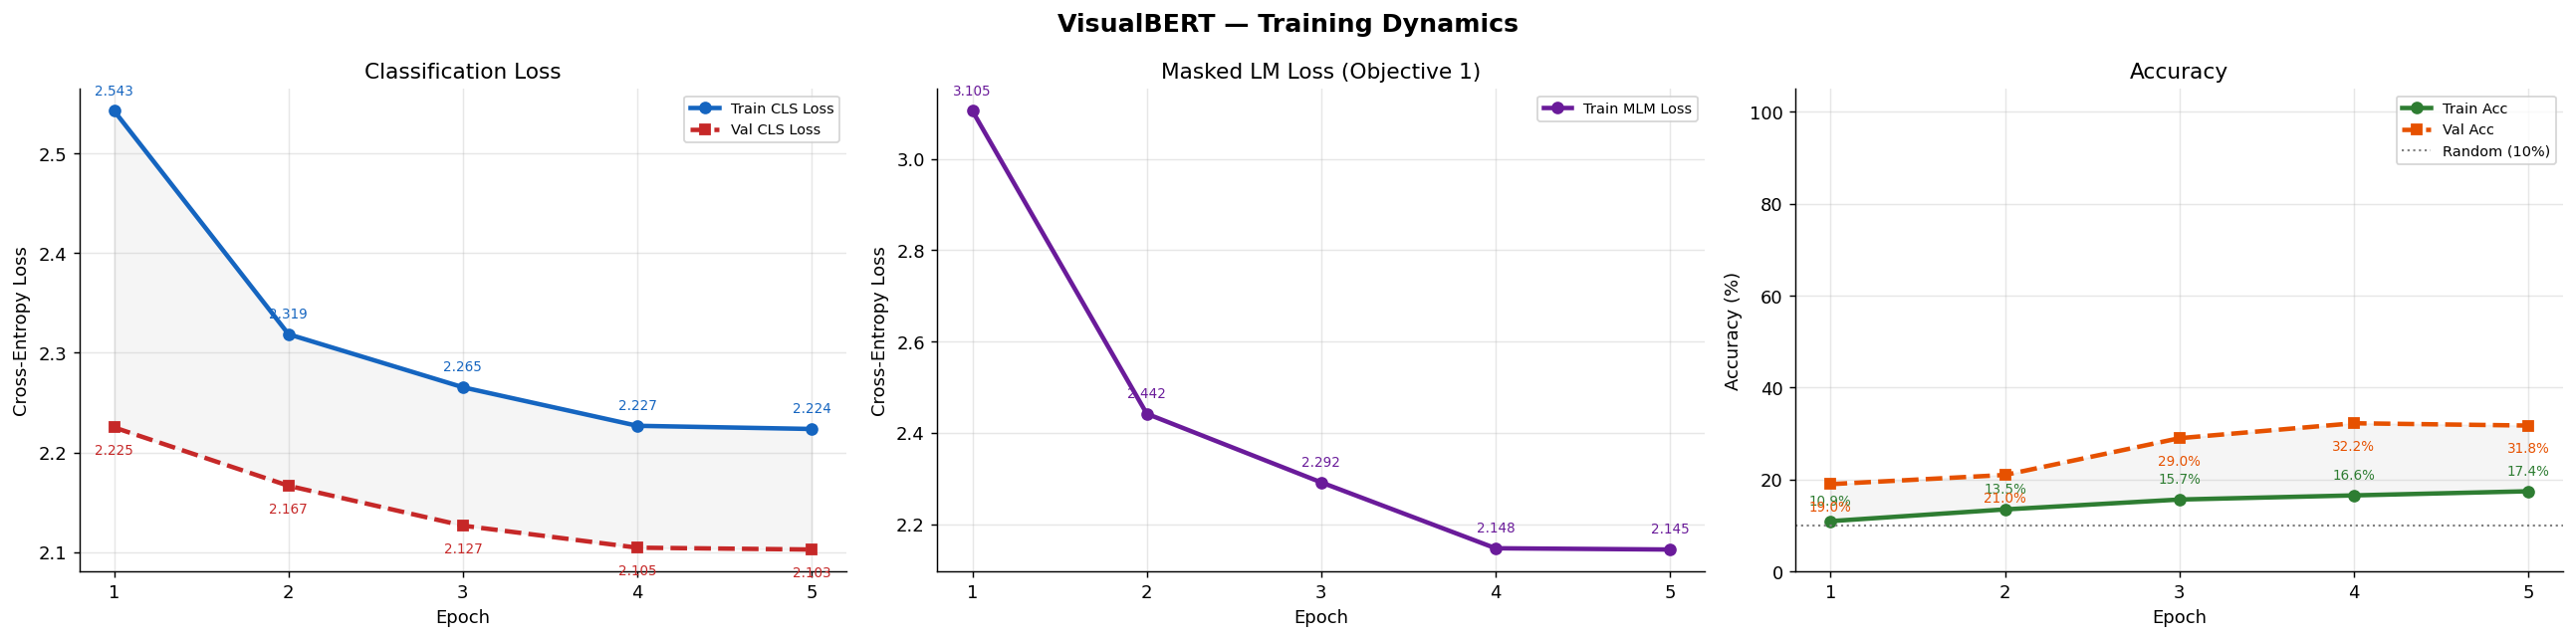

In [12]:
# ============================================================
# VISUALIZATION 1 — LOSS & ACCURACY CURVES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("VisualBERT — Training Dynamics",
             fontsize=14, fontweight="bold")

# --- Classification loss ---
ax = axes[0]
ax.plot(epochs_x, history["tr_cls"], "o-",
        color="#1565C0", lw=2.5, label="Train CLS Loss")
ax.plot(epochs_x, history["va_loss"], "s--",
        color="#C62828", lw=2.5, label="Val CLS Loss")
ax.fill_between(epochs_x, history["tr_cls"],
                history["va_loss"], alpha=0.08, color="gray")
for i, (tl, vl) in enumerate(
        zip(history["tr_cls"], history["va_loss"])):
    ax.annotate(f"{tl:.3f}", (epochs_x[i], tl),
                xytext=(0, 9), textcoords="offset points",
                fontsize=7.5, color="#1565C0", ha="center")
    ax.annotate(f"{vl:.3f}", (epochs_x[i], vl),
                xytext=(0, -15), textcoords="offset points",
                fontsize=7.5, color="#C62828", ha="center")
ax.set_title("Classification Loss"); ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss"); ax.set_xticks(epochs_x)
ax.legend(fontsize=8)

# --- MLM loss ---
ax = axes[1]
ax.plot(epochs_x, history["tr_mlm"], "o-",
        color="#6A1B9A", lw=2.5, label="Train MLM Loss")
for i, ml in enumerate(history["tr_mlm"]):
    ax.annotate(f"{ml:.3f}", (epochs_x[i], ml),
                xytext=(0, 9), textcoords="offset points",
                fontsize=7.5, color="#6A1B9A", ha="center")
ax.set_title("Masked LM Loss (Objective 1)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_xticks(epochs_x); ax.legend(fontsize=8)

# --- Accuracy ---
ax = axes[2]
ax.plot(epochs_x, history["tr_acc"], "o-",
        color="#2E7D32", lw=2.5, label="Train Acc")
ax.plot(epochs_x, history["va_acc"], "s--",
        color="#E65100", lw=2.5, label="Val Acc")
ax.axhline(10, color="gray", ls=":", lw=1.2,
           label="Random (10%)")
ax.fill_between(epochs_x, history["tr_acc"],
                history["va_acc"], alpha=0.08, color="gray")
for i, (ta, va) in enumerate(
        zip(history["tr_acc"], history["va_acc"])):
    ax.annotate(f"{ta:.1f}%", (epochs_x[i], ta),
                xytext=(0, 9), textcoords="offset points",
                fontsize=7.5, color="#2E7D32", ha="center")
    ax.annotate(f"{va:.1f}%", (epochs_x[i], va),
                xytext=(0, -15), textcoords="offset points",
                fontsize=7.5, color="#E65100", ha="center")
ax.set_title("Accuracy"); ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)"); ax.set_xticks(epochs_x)
ax.set_ylim(0, 105); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("vbert_viz1_loss_acc.png",
            dpi=150, bbox_inches="tight")
plt.show()

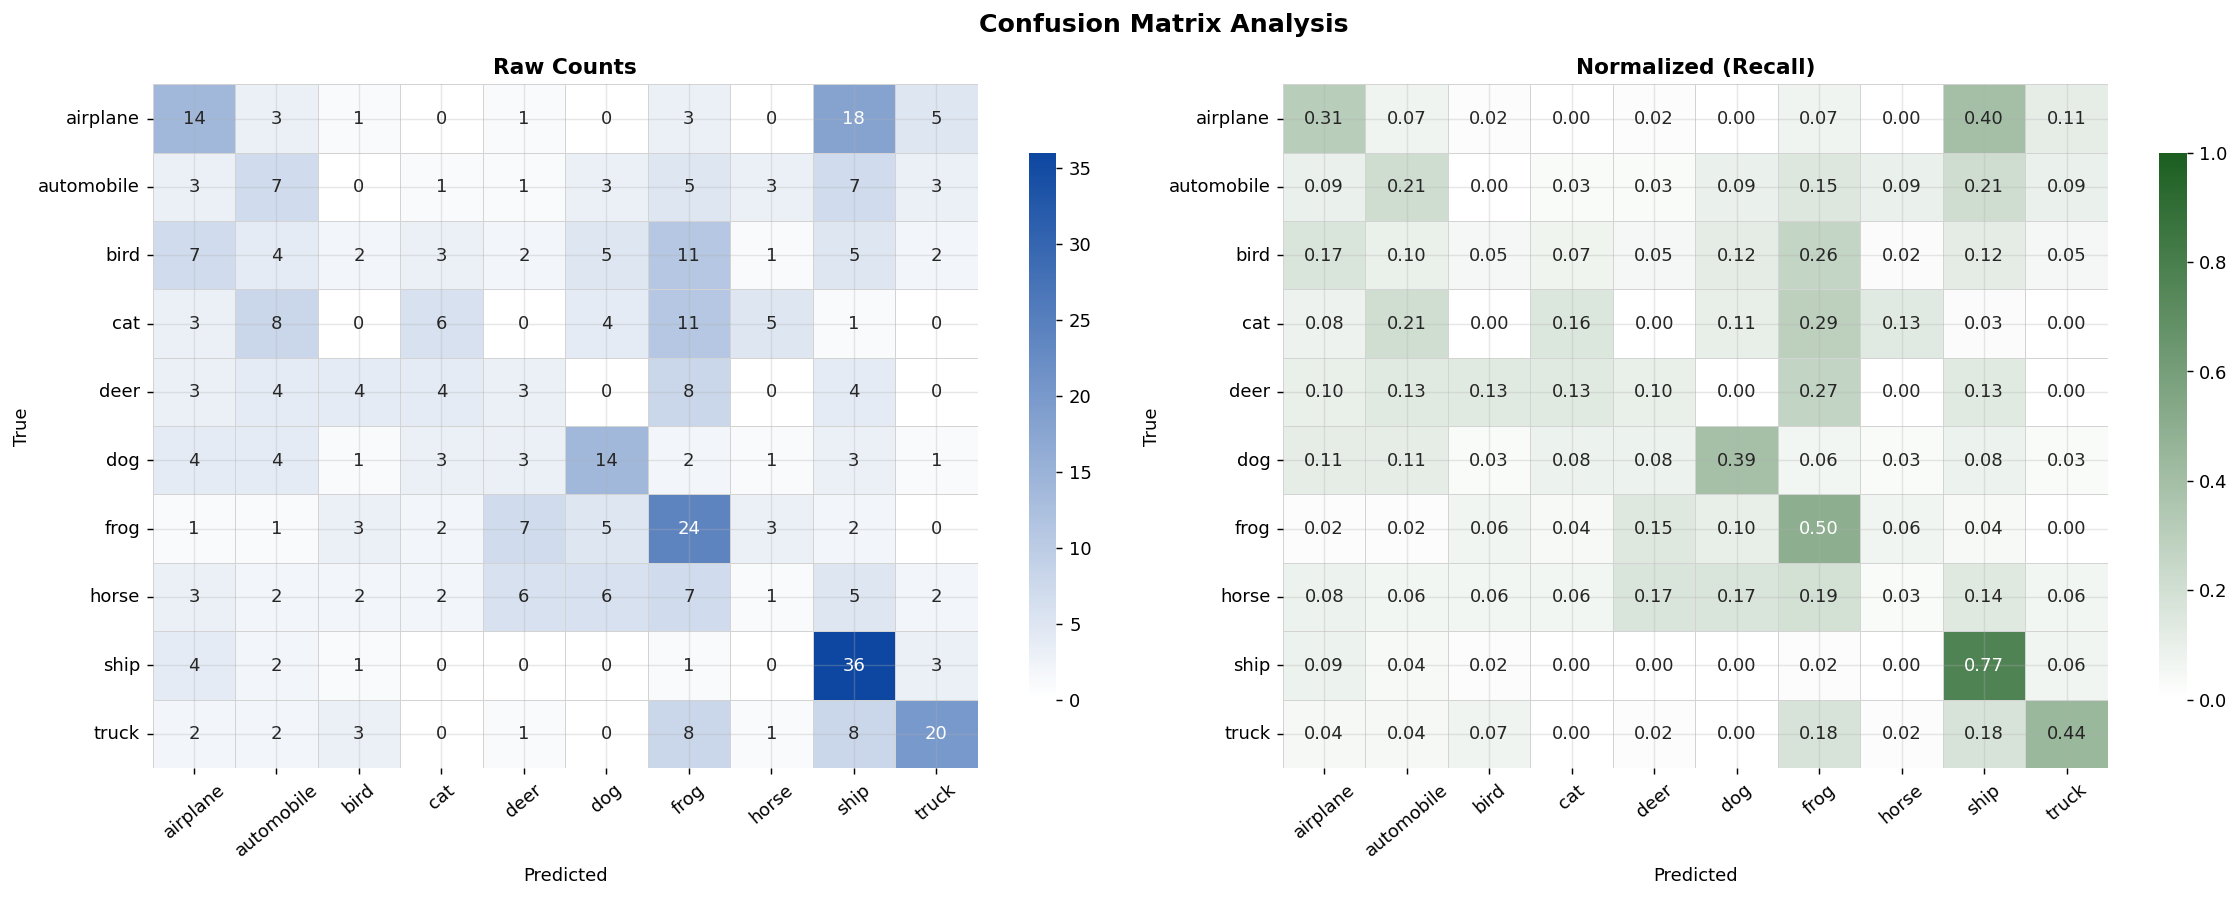

In [13]:
# ============================================================
# VISUALIZATION 2 — CONFUSION MATRICES (RAW + NORMALIZED)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix Analysis",
             fontsize=14, fontweight="bold")

cmap_blue  = LinearSegmentedColormap.from_list(
    "bw", ["#FFFFFF", "#0D47A1"])
cmap_green = LinearSegmentedColormap.from_list(
    "gw", ["#FFFFFF", "#1B5E20"])

sns.heatmap(cm, annot=True, fmt="d", cmap=cmap_blue,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Raw Counts", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=40)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            cmap=cmap_green,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            ax=axes[1], cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1)
axes[1].set_title("Normalized (Recall)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("vbert_viz2_confusion.png",
            dpi=150, bbox_inches="tight")
plt.show()

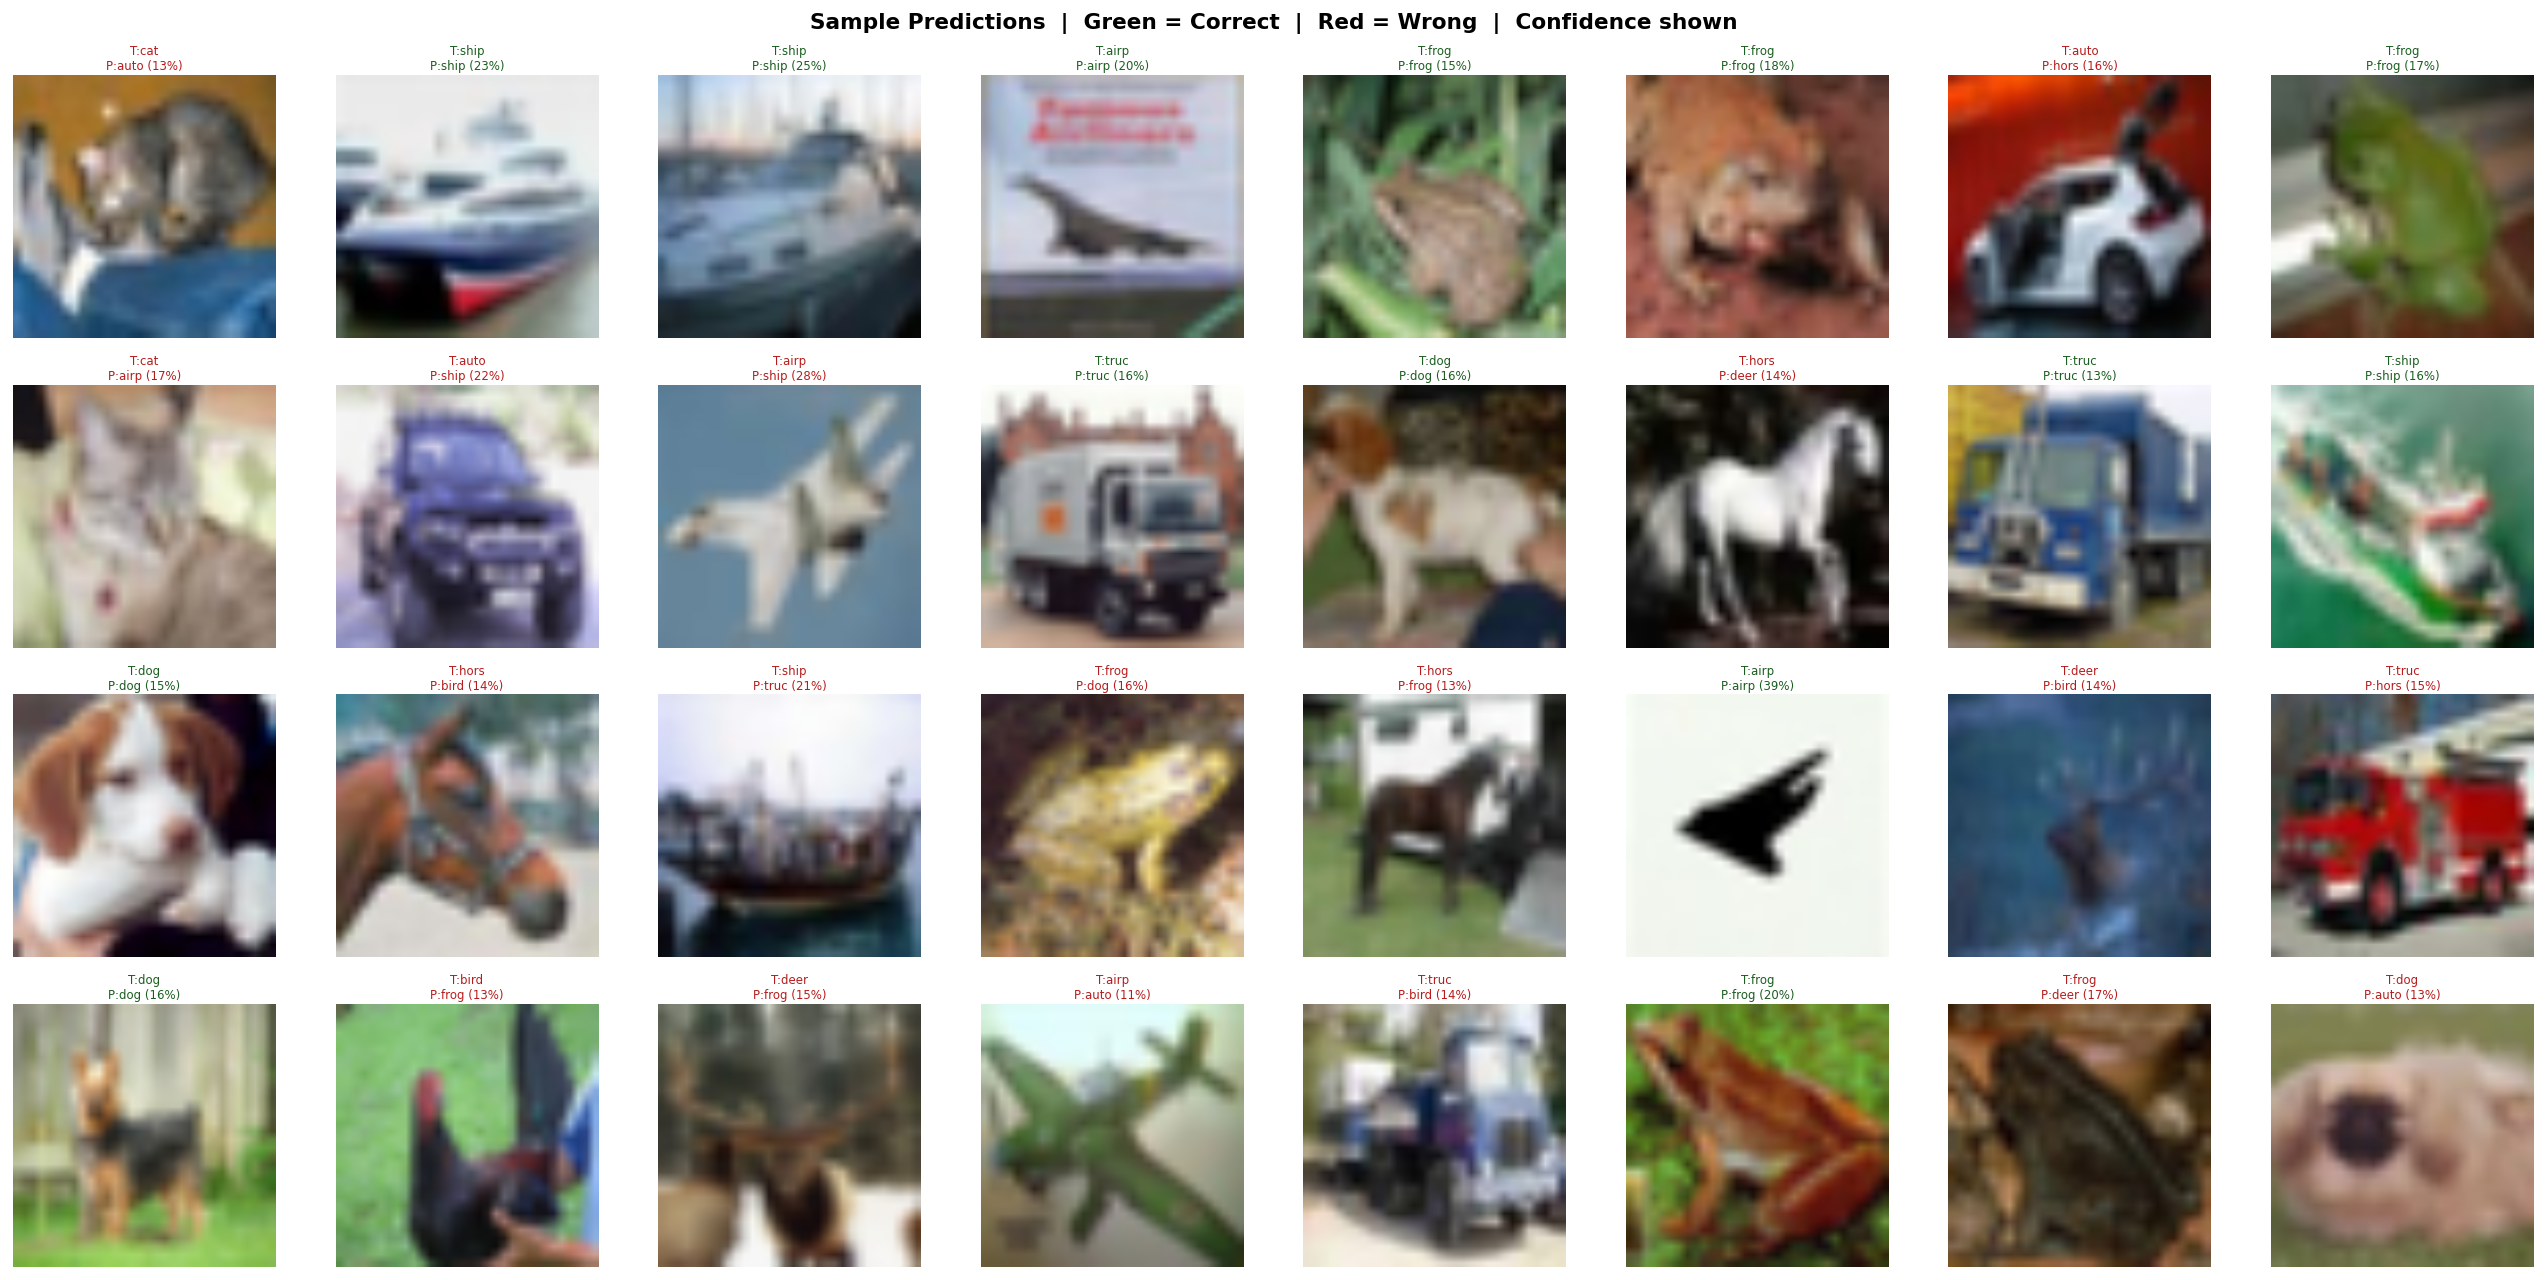

In [14]:
# ============================================================
# VISUALIZATION 3 — SAMPLE PREDICTIONS GRID (32 IMAGES)
# ============================================================

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle(
    "Sample Predictions  |  Green = Correct  |  Red = Wrong  "
    "|  Confidence shown",
    fontsize=12, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    if idx >= len(s_imgs):
        ax.axis("off"); continue
    img_np = denorm(s_imgs[idx]).permute(1, 2, 0).numpy()
    ax.imshow(img_np, interpolation="bilinear")
    ax.axis("off")
    correct = (s_labels[idx] == s_preds[idx])
    col     = "#1B5E20" if correct else "#B71C1C"
    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(col)
        ax.spines[spine].set_linewidth(3)
    ax.set_title(
        f"T:{CIFAR10_CLASSES[s_labels[idx]][:4]}\n"
        f"P:{CIFAR10_CLASSES[s_preds[idx]][:4]} "
        f"({s_confs[idx]*100:.0f}%)",
        fontsize=6.5, color=col, pad=3)

plt.tight_layout()
plt.savefig("vbert_viz3_predictions.png",
            dpi=150, bbox_inches="tight")
plt.show()

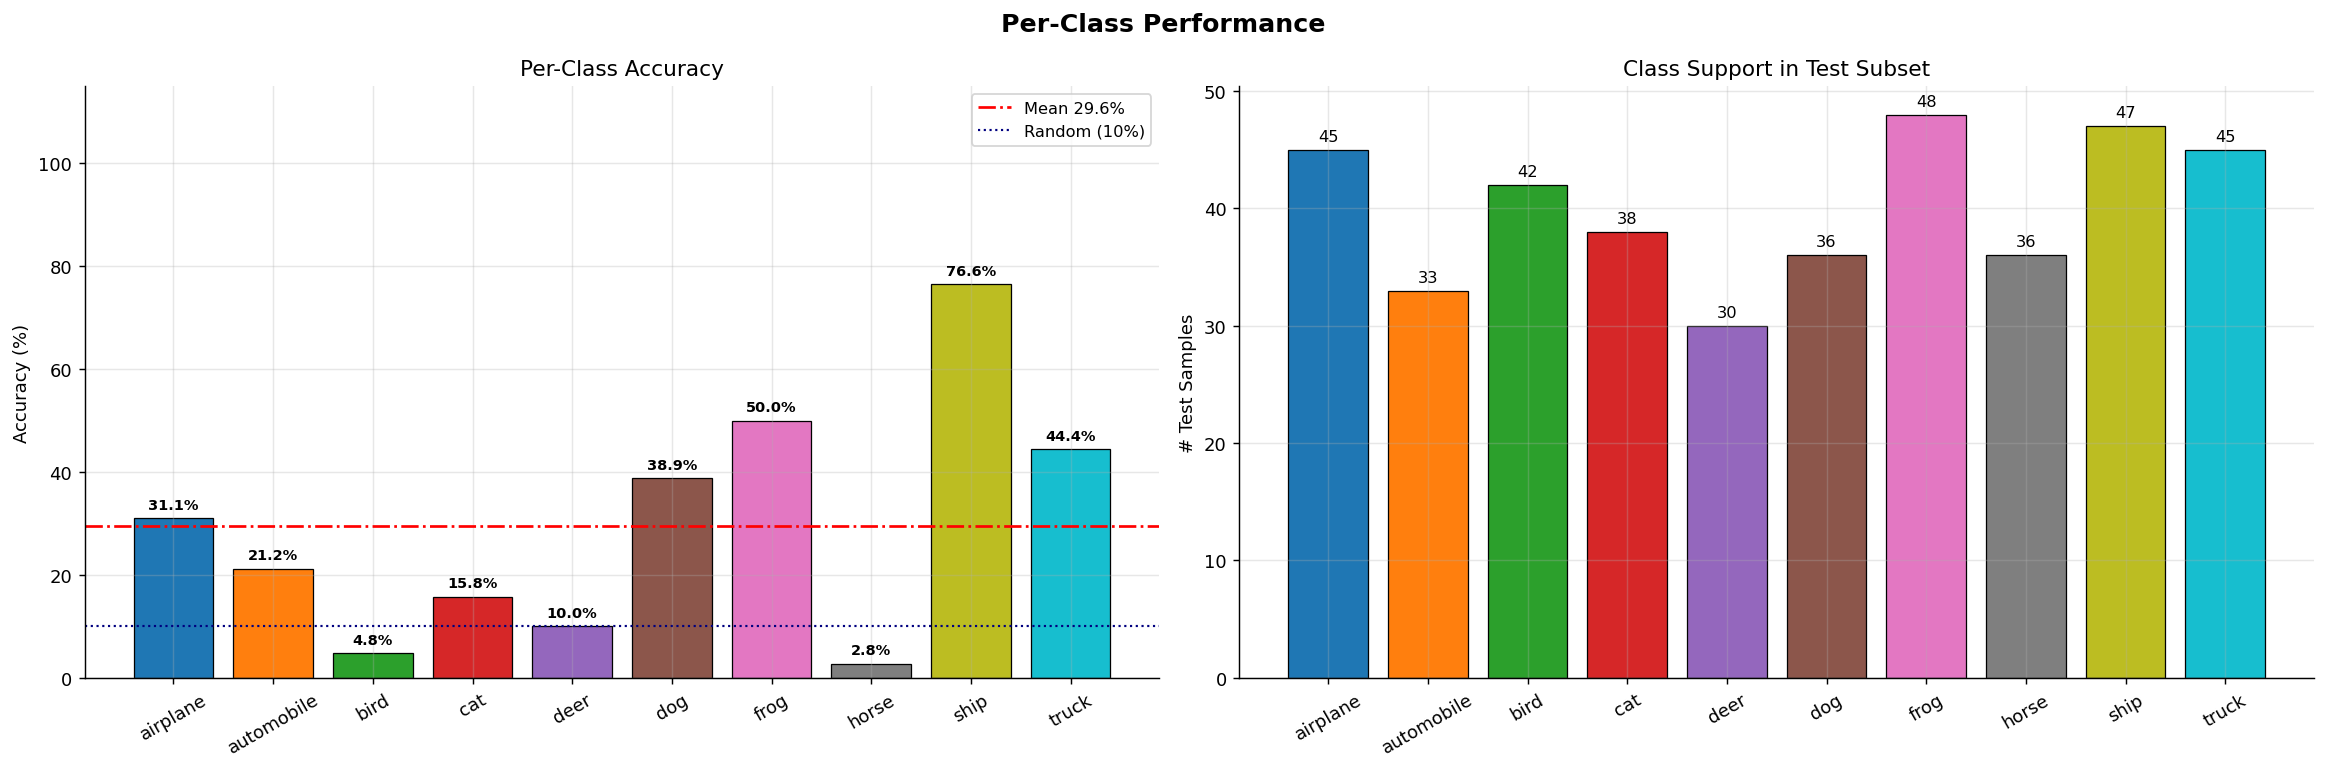

In [15]:
# ============================================================
# VISUALIZATION 4 — PER-CLASS ACCURACY & SUPPORT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Per-Class Performance",
             fontsize=14, fontweight="bold")

# Accuracy bars
ax = axes[0]
bars = ax.bar(CIFAR10_CLASSES, per_class_acc,
              color=CLASS_COLORS, edgecolor="black", lw=0.7)
ax.axhline(np.mean(per_class_acc), color="red",
           ls="-.", lw=1.5,
           label=f"Mean {np.mean(per_class_acc):.1f}%")
ax.axhline(10, color="navy", ls=":", lw=1.2,
           label="Random (10%)")
for b, a in zip(bars, per_class_acc):
    ax.text(b.get_x() + b.get_width()/2, a + 1.2,
            f"{a:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")
ax.set_ylim(0, 115); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=9)

# Support bars
ax = axes[1]
support = [cm[c].sum() for c in range(NUM_CLASSES)]
ax.bar(CIFAR10_CLASSES, support,
       color=CLASS_COLORS, edgecolor="black", lw=0.7)
for i, s in enumerate(support):
    ax.text(i, s + 0.5, str(s),
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("# Test Samples")
ax.set_title("Class Support in Test Subset")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("vbert_viz4_perclass.png",
            dpi=150, bbox_inches="tight")
plt.show()

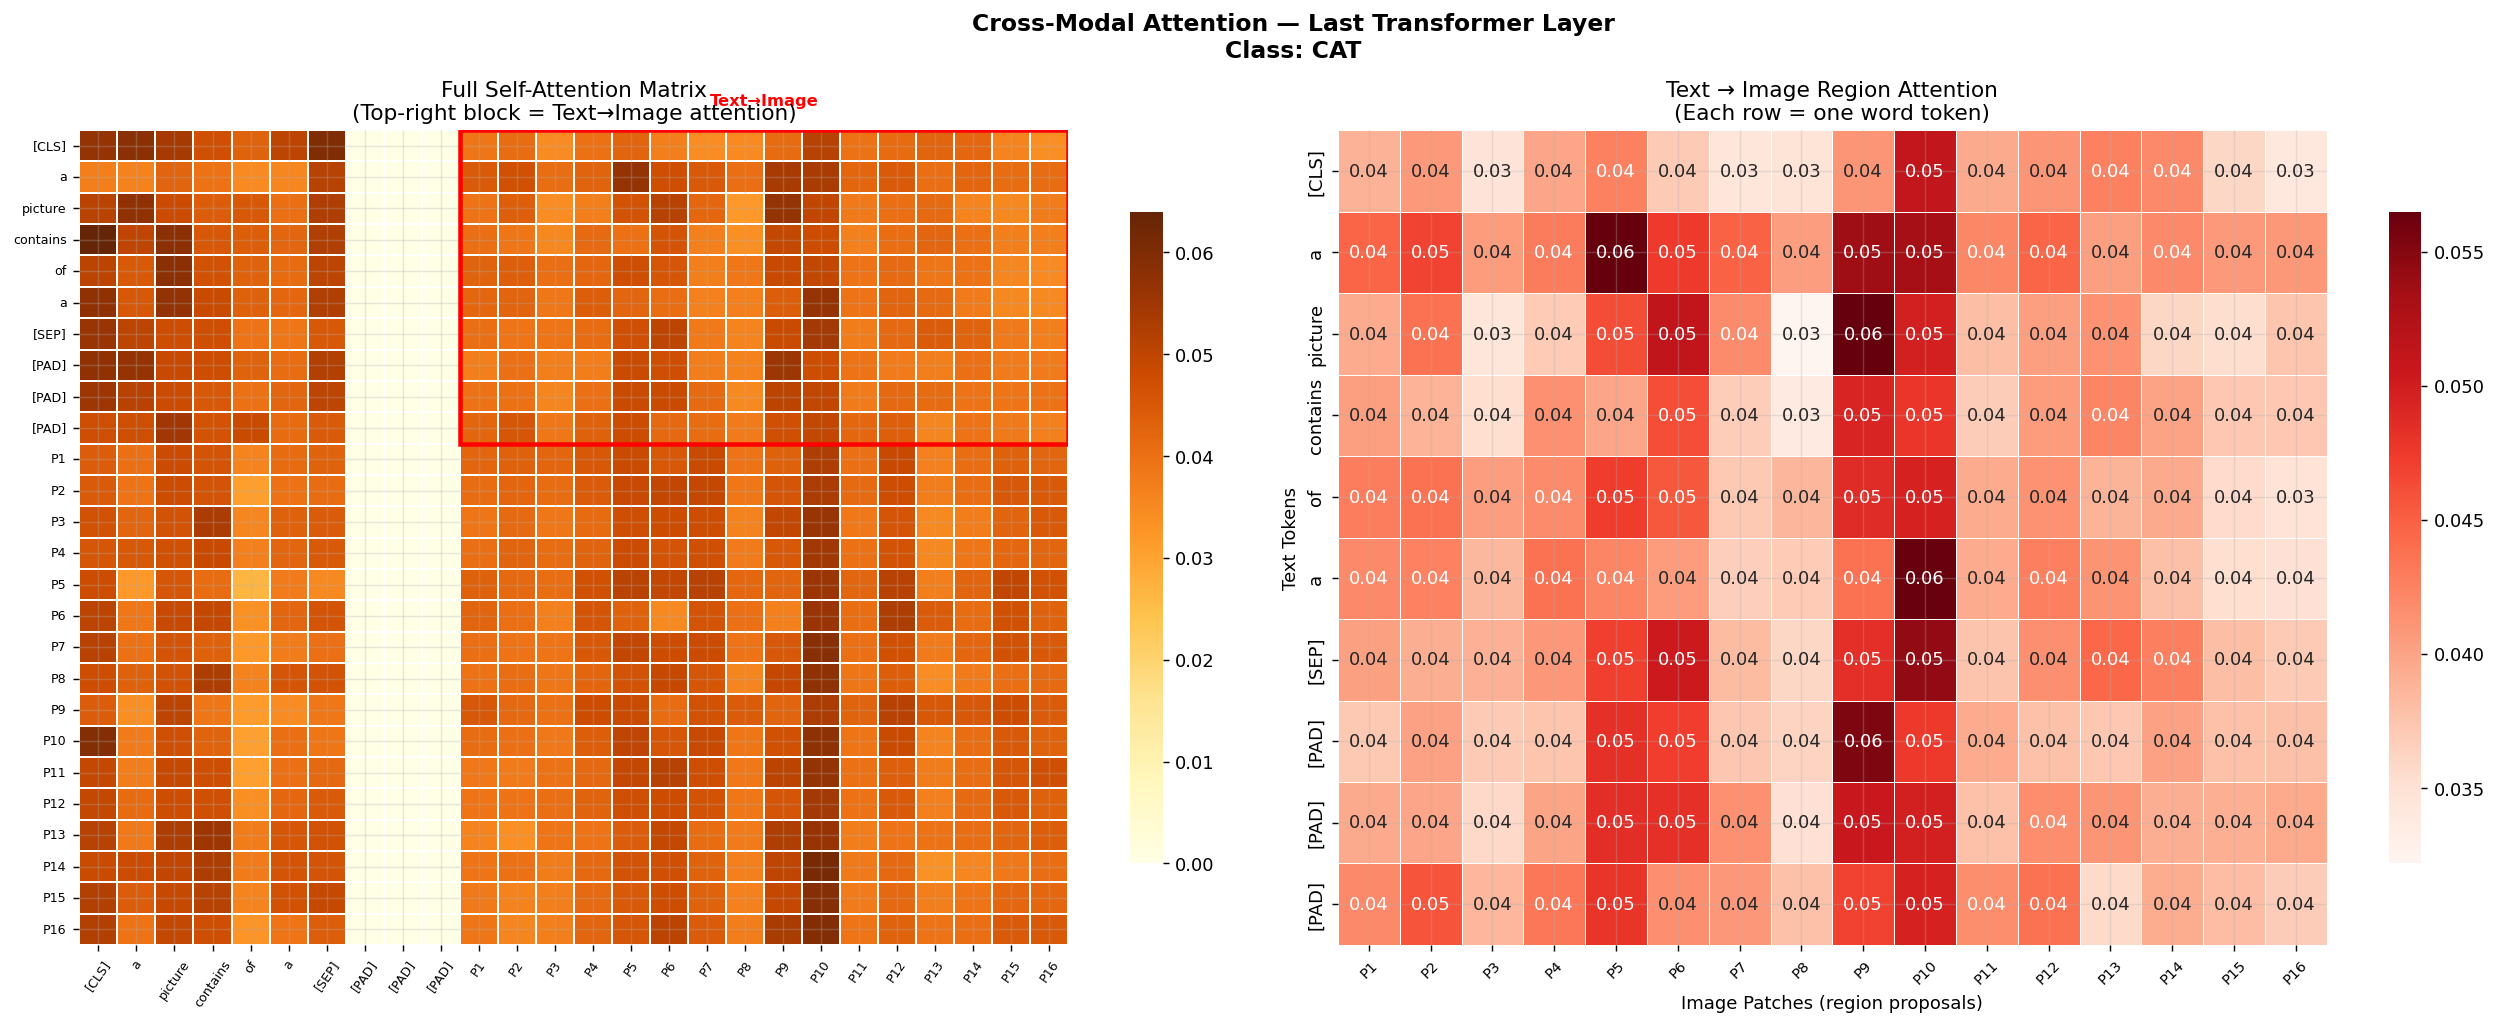

In [16]:
# ============================================================
# VISUALIZATION 5 — CROSS-MODAL ATTENTION HEATMAP
# ============================================================
# VisualBERT's core claim is that self-attention implicitly
# aligns text tokens and image regions.  We visualize the
# attention weights from the last Transformer layer for one
# sample — rows = tokens (text + patches), cols = same.
# The top-right quadrant shows text→image attention.
# ============================================================

model.eval()
with torch.no_grad():
    sample_img   = s_imgs[0].unsqueeze(0).to(DEVICE)
    sample_label = s_labels[0]
    sample_tok   = caption_to_tokens(sample_label)\
                       .unsqueeze(0).to(DEVICE)
    _, attn_all, _ = model(sample_img, sample_tok,
                           return_attn=True)

# Average attention over heads for the last layer
last_layer_attn = attn_all[-1]            # (1, H, L+P, L+P)
avg_attn        = last_layer_attn[0].mean(0).cpu().numpy()
# (L+P, L+P)

L = MAX_TEXT_LEN
P = N_PATCHES
tok_labels = [
    list(VOCAB.keys())[list(VOCAB.values()).index(
        caption_to_tokens(sample_label)[i].item())]
    for i in range(L)
] + [f"P{j+1}" for j in range(P)]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    f"Cross-Modal Attention — Last Transformer Layer\n"
    f"Class: {CIFAR10_CLASSES[sample_label].upper()}",
    fontsize=13, fontweight="bold")

# Full attention matrix
ax = axes[0]
sns.heatmap(avg_attn, cmap="YlOrBr",
            xticklabels=tok_labels,
            yticklabels=tok_labels,
            ax=ax, cbar_kws={"shrink": 0.8},
            linewidths=0.2, linecolor="white")
ax.set_title("Full Self-Attention Matrix\n"
             "(Top-right block = Text→Image attention)")
ax.tick_params(axis="x", rotation=55, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
# Draw rectangle around text→image quadrant
ax.add_patch(mpatches.Rectangle(
    (L, 0), P, L,
    fill=False, edgecolor="red", lw=2.5, zorder=5))
ax.text(L + P/2, -0.8, "Text→Image",
        ha="center", color="red",
        fontsize=9, fontweight="bold")

# Text → image attention only
ax = axes[1]
text2img = avg_attn[:L, L:]    # (L, P)
sns.heatmap(text2img, cmap="Reds",
            xticklabels=[f"P{j+1}" for j in range(P)],
            yticklabels=tok_labels[:L],
            ax=ax, annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.8},
            linewidths=0.3, linecolor="white")
ax.set_title("Text → Image Region Attention\n"
             "(Each row = one word token)")
ax.set_xlabel("Image Patches (region proposals)")
ax.set_ylabel("Text Tokens")
ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig("vbert_viz5_attention.png",
            dpi=150, bbox_inches="tight")
plt.show()

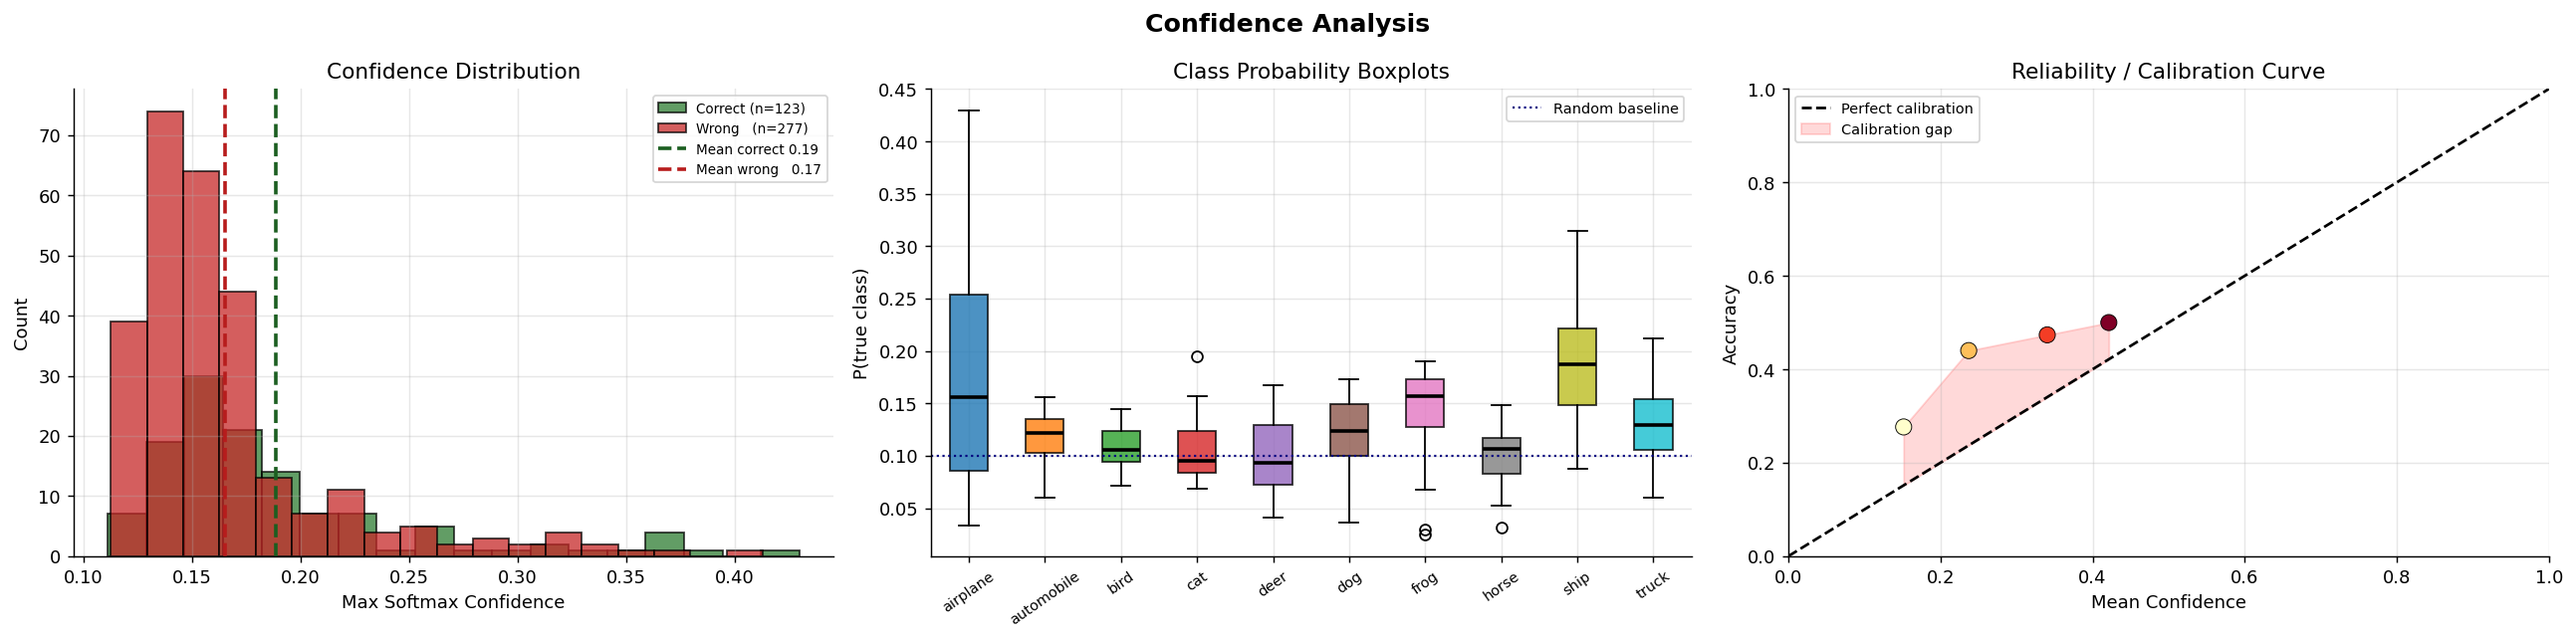

In [17]:
# ============================================================
# VISUALIZATION 6 — CONFIDENCE DISTRIBUTION
# ============================================================

model.eval()
confs_correct, confs_wrong = [], []
probs_matrix = np.zeros((SUBSET_TEST, NUM_CLASSES))
ptr = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        toks   = torch.stack([
            caption_to_tokens(l.item()) for l in labels
        ]).to(DEVICE)
        logits, _, _ = model(imgs, toks)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = probs.argmax(1)
        bs     = imgs.size(0)
        probs_matrix[ptr:ptr+bs] = probs
        ptr += bs
        for i in range(bs):
            conf = probs[i].max()
            if preds[i] == labels[i].item():
                confs_correct.append(conf)
            else:
                confs_wrong.append(conf)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Confidence Analysis",
             fontsize=14, fontweight="bold")

# Histogram
ax = axes[0]
ax.hist(confs_correct, bins=18, color="#2E7D32", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Correct (n={len(confs_correct)})")
ax.hist(confs_wrong,   bins=18, color="#C62828", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Wrong   (n={len(confs_wrong)})")
ax.axvline(np.mean(confs_correct), color="#1B5E20",
           ls="--", lw=2,
           label=f"Mean correct {np.mean(confs_correct):.2f}")
ax.axvline(np.mean(confs_wrong), color="#B71C1C",
           ls="--", lw=2,
           label=f"Mean wrong   {np.mean(confs_wrong):.2f}")
ax.set_xlabel("Max Softmax Confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution")
ax.legend(fontsize=7.5)

# Per-class probability boxplot
ax = axes[1]
box_data = [
    probs_matrix[
        [i for i, l in enumerate(final_labels) if l == c], c
    ].tolist()
    for c in range(NUM_CLASSES)
]
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color="black", lw=2))
for patch, col in zip(bp["boxes"], CLASS_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, fontsize=8)
ax.set_ylabel("P(true class)")
ax.set_title("Class Probability Boxplots")
ax.axhline(0.1, color="navy", ls=":", lw=1.2,
           label="Random baseline")
ax.legend(fontsize=8)

# Calibration curve
ax = axes[2]
bins         = np.linspace(0, 1, 11)
all_confs_a  = probs_matrix.max(1)
all_correct  = (probs_matrix.argmax(1) ==
                np.array(final_labels[:ptr])).astype(float)
bin_acc, bin_conf = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (all_confs_a >= lo) & (all_confs_a < hi)
    if mask.sum():
        bin_acc.append(all_correct[mask].mean())
        bin_conf.append(all_confs_a[mask].mean())
ax.plot([0, 1], [0, 1], "k--", lw=1.5,
        label="Perfect calibration")
ax.scatter(bin_conf, bin_acc, s=80, zorder=5,
           edgecolors="black", lw=0.5, cmap="YlOrRd",
           c=range(len(bin_conf)))
ax.fill_between(bin_conf, bin_acc, bin_conf,
                alpha=0.15, color="red",
                label="Calibration gap")
ax.set_xlabel("Mean Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Reliability / Calibration Curve")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("vbert_viz6_confidence.png",
            dpi=150, bbox_inches="tight")
plt.show()

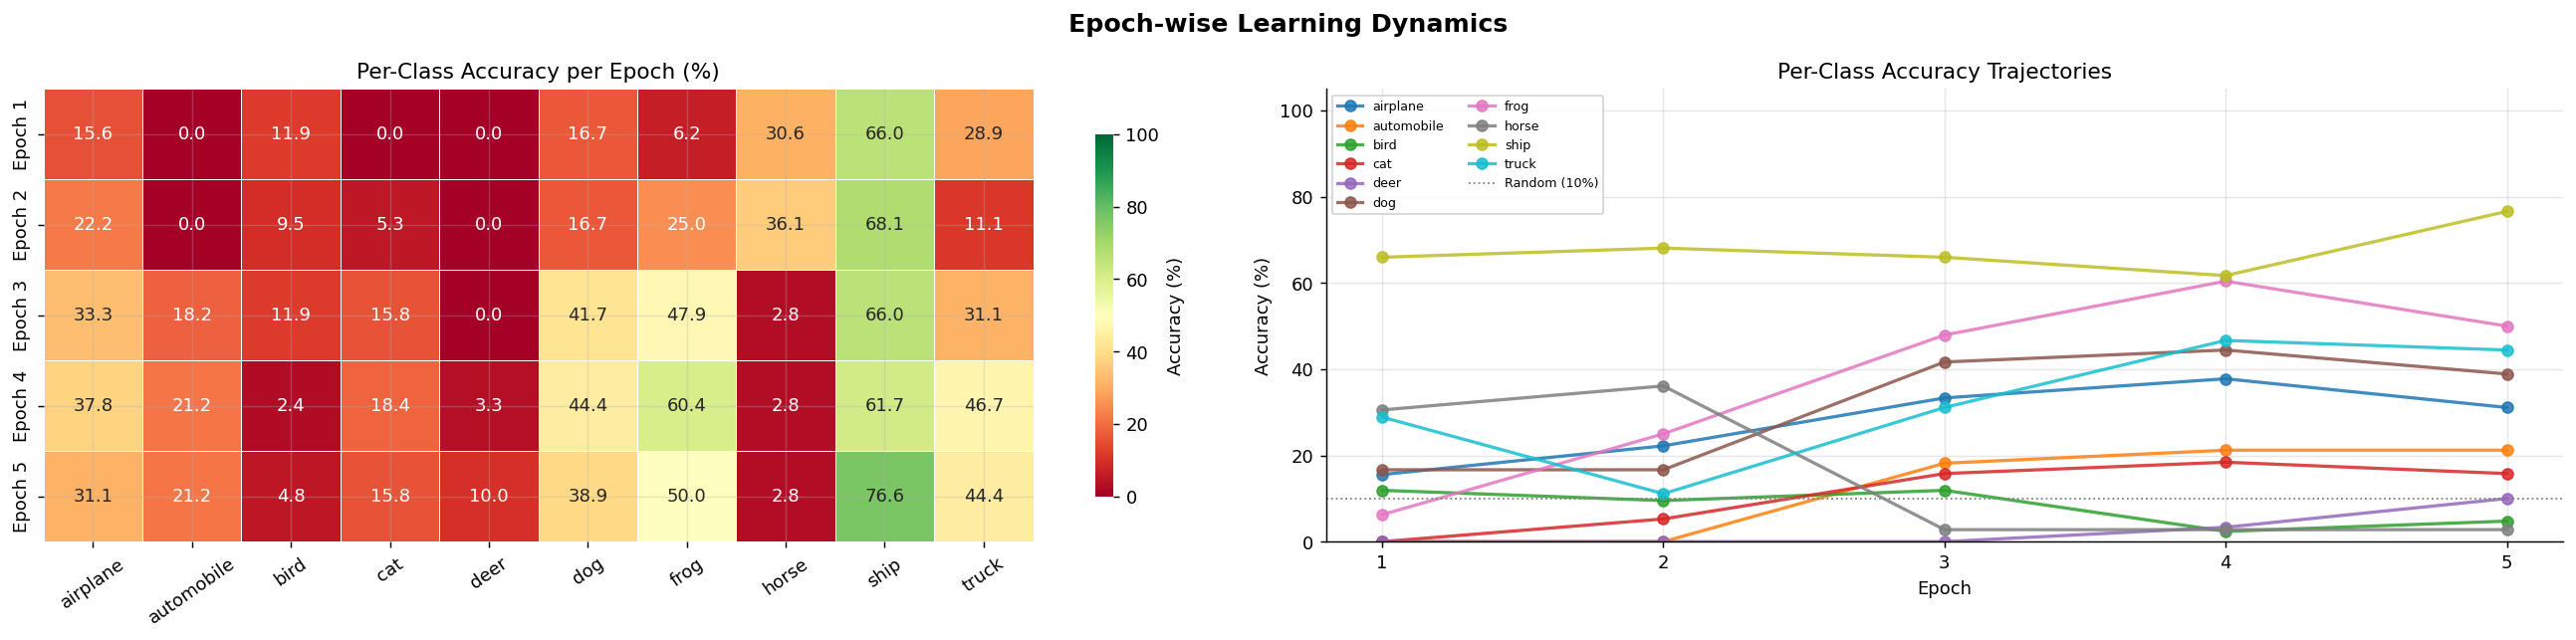

In [18]:
# ============================================================
# VISUALIZATION 7 — EPOCH-WISE PER-CLASS ACCURACY HEATMAP
# ============================================================

epoch_cls_acc = np.zeros((NUM_EPOCHS, NUM_CLASSES))
for ep in range(NUM_EPOCHS):
    cm_ep = confusion_matrix(
        history["v_lbls"][ep], history["v_preds"][ep],
        labels=list(range(NUM_CLASSES)))
    for c in range(NUM_CLASSES):
        if cm_ep[c].sum():
            epoch_cls_acc[ep, c] = (
                100 * cm_ep[c, c] / cm_ep[c].sum())

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("Epoch-wise Learning Dynamics",
             fontsize=14, fontweight="bold")

sns.heatmap(epoch_cls_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"Epoch {e}"
                         for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Accuracy (%)", "shrink": 0.8},
            ax=axes[0])
axes[0].set_title("Per-Class Accuracy per Epoch (%)")
axes[0].tick_params(axis="x", rotation=35)

ax = axes[1]
for c in range(NUM_CLASSES):
    ax.plot(range(1, NUM_EPOCHS+1), epoch_cls_acc[:, c],
            "o-", lw=1.8, color=CLASS_COLORS[c],
            label=CIFAR10_CLASSES[c], alpha=0.85)
ax.axhline(10, color="gray", ls=":", lw=1,
           label="Random (10%)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy Trajectories")
ax.set_xticks(range(1, NUM_EPOCHS+1))
ax.legend(fontsize=7, ncol=2); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("vbert_viz7_epoch_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

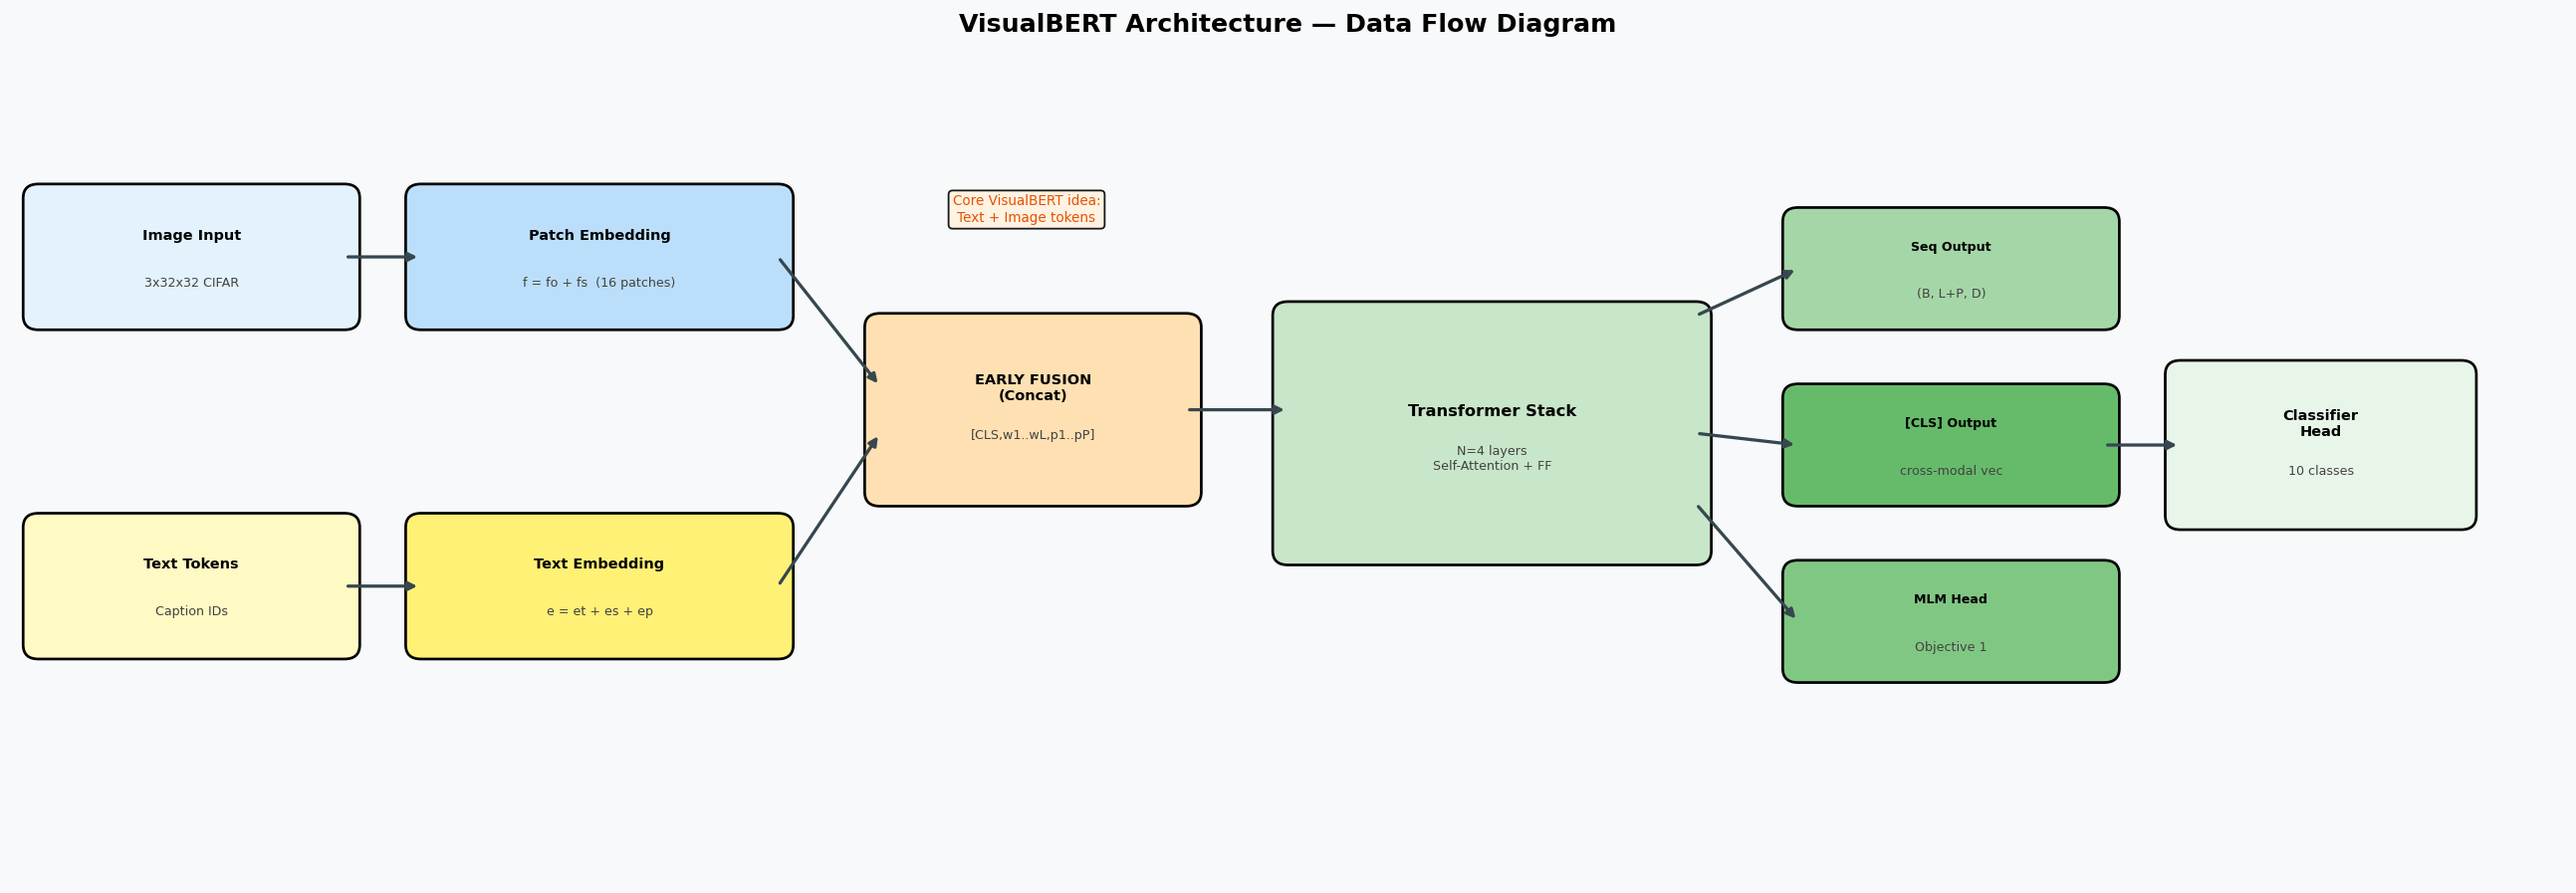

In [19]:
# ============================================================
# VISUALIZATION 8 — ARCHITECTURE DIAGRAM
# ============================================================

fig, ax = plt.subplots(figsize=(20, 7))
ax.set_xlim(0, 20); ax.set_ylim(0, 7)
ax.axis("off"); fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")
ax.set_title("VisualBERT Architecture — Data Flow Diagram",
             fontsize=14, fontweight="bold", pad=14)

def box(ax, x, y, w, h, fc, label, sub="", fs=9):
    r = mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.12",
        lw=1.5, edgecolor="black", facecolor=fc, zorder=3)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2 + (0.18 if sub else 0),
            label, ha="center", va="center",
            fontsize=fs, fontweight="bold", zorder=4)
    if sub:
        ax.text(x+w/2, y+h/2-0.22, sub,
                ha="center", va="center",
                fontsize=7, color="#424242", zorder=4)

def arr(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>",
                                color="#37474F", lw=1.8),
                zorder=5)

# Input blocks
box(ax, 0.2, 4.8, 2.4, 1.0, "#E3F2FD",
    "Image Input",  "3x32x32 CIFAR", 8)
box(ax, 0.2, 2.0, 2.4, 1.0, "#FFF9C4",
    "Text Tokens",  "Caption IDs", 8)

# Embedding blocks
box(ax, 3.2, 4.8, 2.8, 1.0, "#BBDEFB",
    "Patch Embedding",
    "f = fo + fs  (16 patches)", 8)
box(ax, 3.2, 2.0, 2.8, 1.0, "#FFF176",
    "Text Embedding",
    "e = et + es + ep", 8)

# EARLY FUSION
box(ax, 6.8, 3.3, 2.4, 1.4, "#FFE0B2",
    "EARLY FUSION\n(Concat)",
    "[CLS,w1..wL,p1..pP]", 8)
ax.text(7.95, 5.6, "Core VisualBERT idea:\nText + Image tokens",
        ha="center", fontsize=7.5, color="#E65100",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="#FFF3E0", alpha=0.9))

# Transformer stack
box(ax, 10.0, 2.8, 3.2, 2.0, "#C8E6C9",
    "Transformer Stack",
    f"N={N_LAYERS} layers\nSelf-Attention + FF", 9)

# Outputs
box(ax, 14.0, 4.8, 2.4, 0.8, "#A5D6A7",
    "Seq Output", "(B, L+P, D)", 7)
box(ax, 14.0, 3.3, 2.4, 0.8, "#66BB6A",
    "[CLS] Output", "cross-modal vec", 7)
box(ax, 14.0, 1.8, 2.4, 0.8, "#81C784",
    "MLM Head",    "Objective 1", 7)

# Classification head
box(ax, 17.0, 3.1, 2.2, 1.2, "#E8F5E9",
    "Classifier\nHead",
    "10 classes", 8)

# Arrows
arr(ax, 2.6, 5.3, 3.2, 5.3)
arr(ax, 2.6, 2.5, 3.2, 2.5)
arr(ax, 6.0, 5.3, 6.8, 4.2)
arr(ax, 6.0, 2.5, 6.8, 3.8)
arr(ax, 9.2, 4.0, 10.0, 4.0)
arr(ax, 13.2, 4.8, 14.0, 5.2)
arr(ax, 13.2, 3.8, 14.0, 3.7)
arr(ax, 13.2, 3.2, 14.0, 2.2)
arr(ax, 16.4, 3.7, 17.0, 3.7)

plt.tight_layout()
plt.savefig("vbert_viz8_architecture.png",
            dpi=150, bbox_inches="tight")
plt.show()

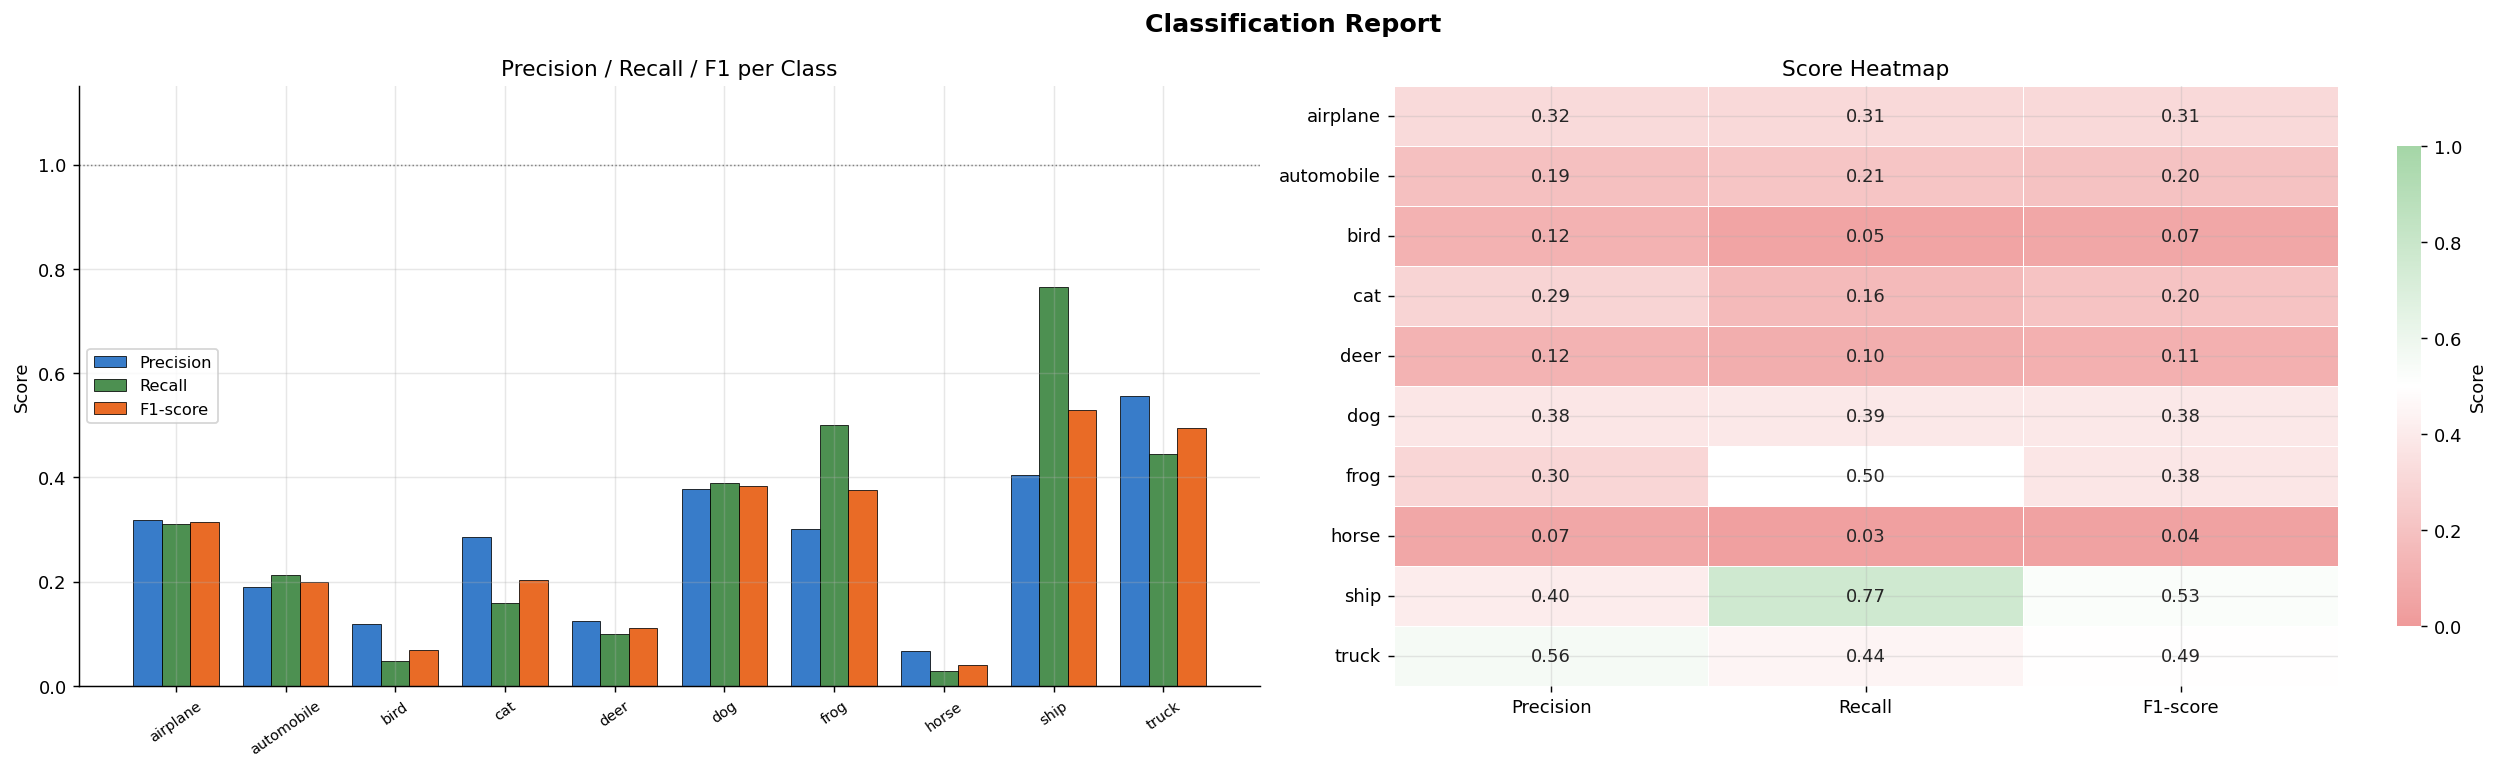

In [20]:
# ============================================================
# VISUALIZATION 9 — CLASSIFICATION REPORT HEATMAP
# ============================================================

report = classification_report(
    final_labels, final_preds,
    target_names=CIFAR10_CLASSES, output_dict=True)
metrics   = ["precision", "recall", "f1-score"]
data_mat  = np.array([
    [report[c][m] for m in metrics]
    for c in CIFAR10_CLASSES])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Classification Report",
             fontsize=14, fontweight="bold")

# Grouped bar chart
ax     = axes[0]
x      = np.arange(NUM_CLASSES)
w      = 0.26
cols_b = ["#1565C0", "#2E7D32", "#E65100"]
for i, (metric, col) in enumerate(zip(metrics, cols_b)):
    ax.bar(x + i*w - w, data_mat[:, i], w,
           label=metric.capitalize(),
           color=col, alpha=0.85,
           edgecolor="black", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, fontsize=8)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.legend(fontsize=9)
ax.set_title("Precision / Recall / F1 per Class")
ax.axhline(1.0, color="gray", ls=":", lw=0.8)

# Heatmap table
cmap_rg = LinearSegmentedColormap.from_list(
    "rg", ["#EF9A9A", "#FFFFFF", "#A5D6A7"])
sns.heatmap(data_mat,
            xticklabels=[m.capitalize() for m in metrics],
            yticklabels=CIFAR10_CLASSES,
            annot=True, fmt=".2f",
            cmap=cmap_rg, vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Score", "shrink": 0.8},
            ax=axes[1])
axes[1].set_title("Score Heatmap")

plt.tight_layout()
plt.savefig("vbert_viz9_report.png",
            dpi=150, bbox_inches="tight")
plt.show()

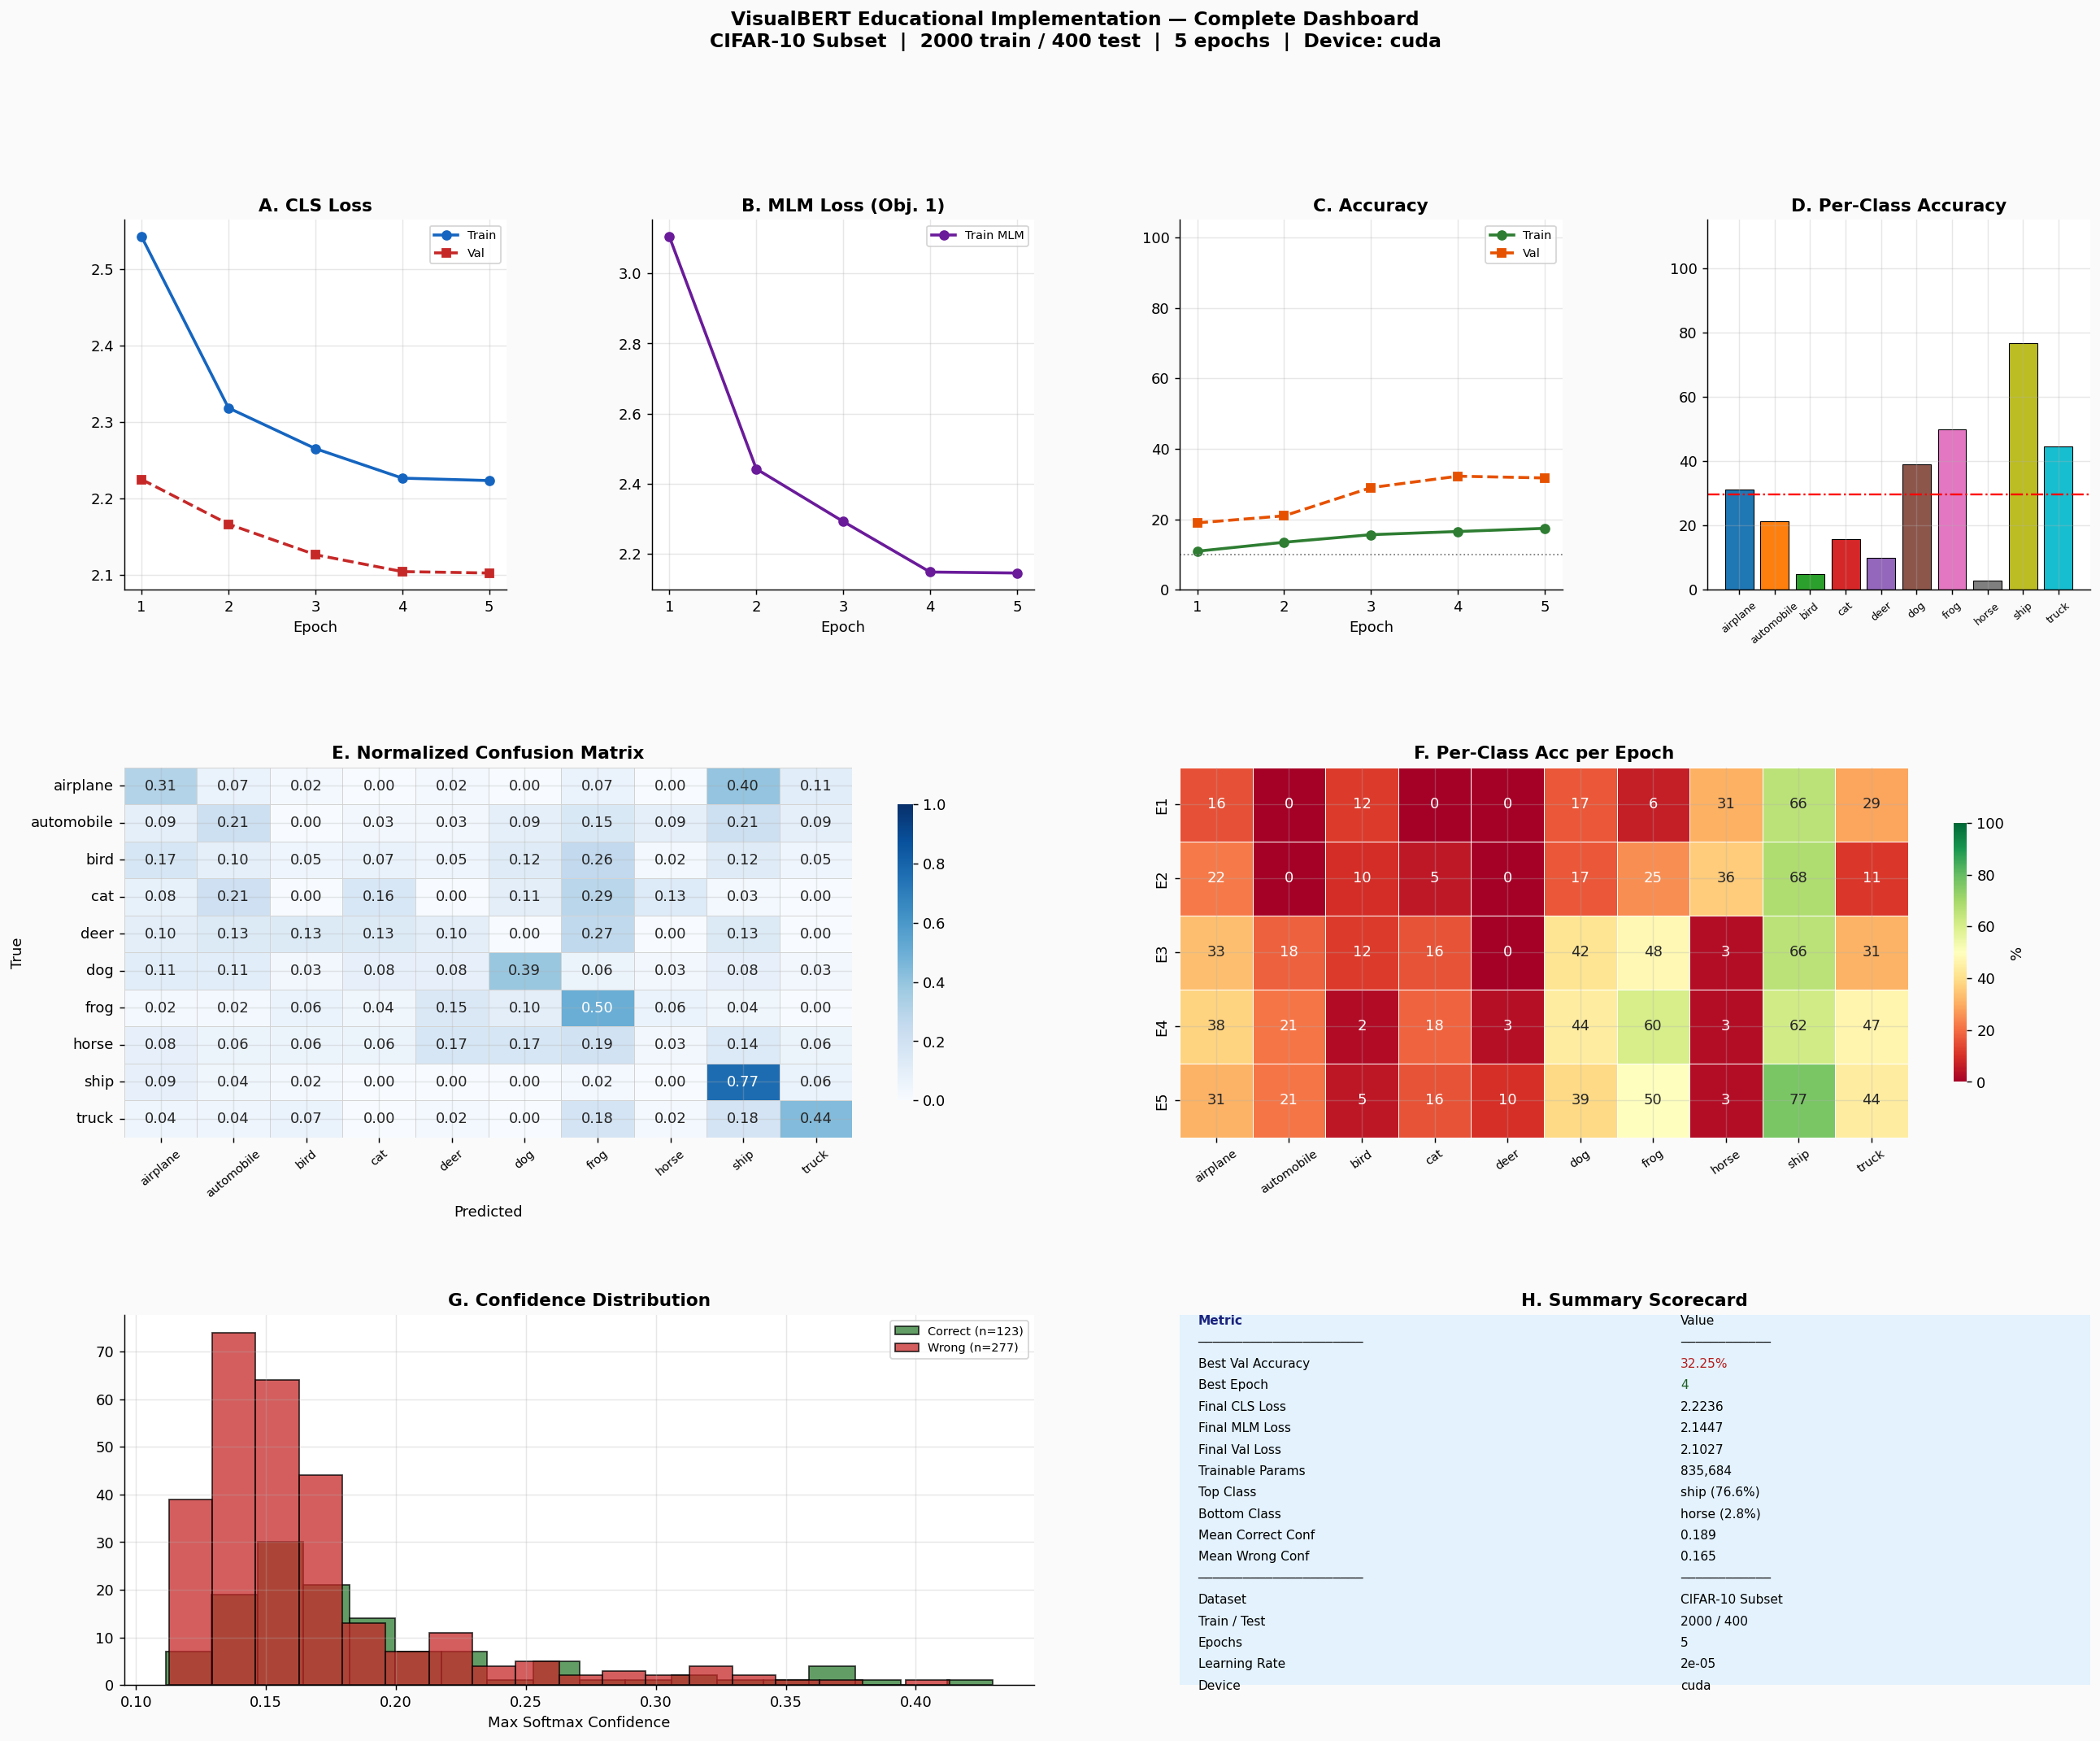

All 10 visualizations saved.


In [21]:
# ============================================================
# VISUALIZATION 10 — COMPLETE RESULTS DASHBOARD
# ============================================================

fig = plt.figure(figsize=(24, 18))
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "VisualBERT Educational Implementation — Complete Dashboard\n"
    f"CIFAR-10 Subset  |  {SUBSET_TRAIN} train / "
    f"{SUBSET_TEST} test  |  {NUM_EPOCHS} epochs  |  "
    f"Device: {DEVICE}",
    fontsize=13, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.48, wspace=0.38)

# A: CLS Loss
ax = fig.add_subplot(gs[0, 0])
ax.plot(epochs_x, history["tr_cls"], "o-",
        color="#1565C0", lw=2, label="Train")
ax.plot(epochs_x, history["va_loss"], "s--",
        color="#C62828", lw=2, label="Val")
ax.set_title("A. CLS Loss", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.legend(fontsize=8)

# B: MLM Loss
ax = fig.add_subplot(gs[0, 1])
ax.plot(epochs_x, history["tr_mlm"], "o-",
        color="#6A1B9A", lw=2, label="Train MLM")
ax.set_title("B. MLM Loss (Obj. 1)", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.legend(fontsize=8)

# C: Accuracy
ax = fig.add_subplot(gs[0, 2])
ax.plot(epochs_x, history["tr_acc"], "o-",
        color="#2E7D32", lw=2, label="Train")
ax.plot(epochs_x, history["va_acc"], "s--",
        color="#E65100", lw=2, label="Val")
ax.axhline(10, color="gray", ls=":", lw=1)
ax.set_title("C. Accuracy", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.set_ylim(0, 105); ax.legend(fontsize=8)

# D: Per-class accuracy
ax = fig.add_subplot(gs[0, 3])
brs = ax.bar(CIFAR10_CLASSES, per_class_acc,
             color=CLASS_COLORS,
             edgecolor="black", lw=0.6)
ax.axhline(np.mean(per_class_acc), color="red",
           ls="-.", lw=1.3)
ax.set_ylim(0, 115)
ax.set_title("D. Per-Class Accuracy", fontweight="bold")
ax.tick_params(axis="x", rotation=40, labelsize=7)

# E: Normalized confusion matrix
ax = fig.add_subplot(gs[1, :2])
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            cmap="Blues", vmin=0, vmax=1,
            linewidths=0.3, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("E. Normalized Confusion Matrix",
             fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=40, labelsize=8)

# F: Epoch heatmap
ax = fig.add_subplot(gs[1, 2:])
sns.heatmap(epoch_cls_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"E{e}"
                         for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.4, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "%"},
            ax=ax)
ax.set_title("F. Per-Class Acc per Epoch",
             fontweight="bold")
ax.tick_params(axis="x", rotation=35, labelsize=8)

# G: Confidence histogram
ax = fig.add_subplot(gs[2, :2])
ax.hist(confs_correct, bins=18, color="#2E7D32",
        alpha=0.75, edgecolor="black", lw=0.4,
        label=f"Correct (n={len(confs_correct)})")
ax.hist(confs_wrong, bins=18, color="#C62828",
        alpha=0.75, edgecolor="black", lw=0.4,
        label=f"Wrong (n={len(confs_wrong)})")
ax.set_title("G. Confidence Distribution",
             fontweight="bold")
ax.set_xlabel("Max Softmax Confidence")
ax.legend(fontsize=8)

# H: Summary scorecard
ax = fig.add_subplot(gs[2, 2:])
ax.axis("off")
best_ep  = history["va_acc"].index(max(history["va_acc"])) + 1
best_acc = max(history["va_acc"])
rows = [
    ("Metric",               "Value"),
    ("─"*22,                 "─"*12),
    ("Best Val Accuracy",    f"{best_acc:.2f}%"),
    ("Best Epoch",           str(best_ep)),
    ("Final CLS Loss",       f"{history['tr_cls'][-1]:.4f}"),
    ("Final MLM Loss",       f"{history['tr_mlm'][-1]:.4f}"),
    ("Final Val Loss",       f"{history['va_loss'][-1]:.4f}"),
    ("Trainable Params",     f"{n_params:,}"),
    ("Top Class",
     f"{CIFAR10_CLASSES[int(np.argmax(per_class_acc))]} "
     f"({max(per_class_acc):.1f}%)"),
    ("Bottom Class",
     f"{CIFAR10_CLASSES[int(np.argmin(per_class_acc))]} "
     f"({min(per_class_acc):.1f}%)"),
    ("Mean Correct Conf",    f"{np.mean(confs_correct):.3f}"),
    ("Mean Wrong Conf",      f"{np.mean(confs_wrong):.3f}"),
    ("─"*22,                 "─"*12),
    ("Dataset",              "CIFAR-10 Subset"),
    ("Train / Test",         f"{SUBSET_TRAIN} / {SUBSET_TEST}"),
    ("Epochs",               str(NUM_EPOCHS)),
    ("Learning Rate",        str(LR)),
    ("Device",               str(DEVICE)),
]
for row_i, (k, v) in enumerate(rows):
    wt   = "bold" if row_i in (0, 1) else "normal"
    col  = "#1A237E" if row_i == 0 else "black"
    vcol = ("#B71C1C" if row_i == 2 else
            "#1B5E20" if row_i == 3 else "black")
    ax.text(0.02, 1 - row_i * 0.058, k,
            transform=ax.transAxes, fontsize=8.5,
            fontweight=wt, color=col, va="top")
    ax.text(0.55,  1 - row_i * 0.058, v,
            transform=ax.transAxes, fontsize=8.5,
            color=vcol, va="top")
ax.set_title("H. Summary Scorecard", fontweight="bold")
rect = mpatches.FancyBboxPatch(
    (0, 0), 1, 1, boxstyle="round,pad=0.02",
    transform=ax.transAxes, lw=1.5,
    edgecolor="#90CAF9", facecolor="#E3F2FD", zorder=0)
ax.add_patch(rect)

plt.savefig("vbert_viz10_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("All 10 visualizations saved.")

# VisualBERT: Related Work — Reference Table

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Devlin et al. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL-HLT | Primary inspiration for VisualBERT; its Transformer architecture, masked LM objective, segment embeddings, and pre-train/fine-tune paradigm are directly adopted and extended to the visual modality. |
| Vaswani et al. | 2017 | Attention Is All You Need | NeurIPS | Foundational Transformer architecture underlying both BERT and VisualBERT; the self-attention mechanism is the core component reused for implicit cross-modal alignment. |
| Ren et al. | 2015 | Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks | NeurIPS | Provides the object proposal system used to extract visual region features fed as input tokens into VisualBERT across multiple downstream tasks. |
| Anderson et al. | 2018 | Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering | CVPR | Established the use of object RoI features as visual representations in vision-language models; VisualBERT builds on this paradigm by incorporating such features into a unified Transformer. |
| Peters et al. | 2018 | Deep Contextualized Word Representations (ELMo) | NAACL-HLT | Part of the pre-training lineage motivating VisualBERT; demonstrates the value of large-scale language model pre-training for transferable representations. |
| Radford et al. | 2018 | Improving Language Understanding by Generative Pre-Training (GPT) | OpenAI | Further motivation for the pre-train/fine-tune paradigm extended by VisualBERT to the cross-modal setting. |
| Radford et al. | 2019 | Language Models Are Unsupervised Multitask Learners (GPT-2) | OpenAI | Cited as part of the broader line of universal language encoder pre-training works that VisualBERT extends to vision-language tasks. |
| Sun et al. | 2019 | VideoBERT: A Joint Model for Video and Language Representation Learning | arXiv | Concurrent work with a similar Transformer-based architecture for joint vision-language modeling; VisualBERT differs by using fine-grained region-level features and evaluating on diverse vision-language benchmarks rather than cooking video captioning. |
| Lu et al. (Jiasen) | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | arXiv | Concurrent cross-modal pre-training model; uses dual Transformer towers with cross-attention, doubling parameters relative to VisualBERT's single unified Transformer; evaluated on overlapping tasks with partially consistent results. |
| Antol et al. | 2015 | VQA: Visual Question Answering | ICCV | Introduced the VQA task and dataset; one of four downstream benchmarks on which VisualBERT is evaluated. |
| Goyal et al. | 2017 | Making the V in VQA Matter: Elevating the Role of Image Understanding in VQA | CVPR | Introduced VQA 2.0, the balanced version of VQA used as the primary VQA evaluation benchmark in VisualBERT. |
| Zellers et al. | 2019 | From Recognition to Cognition: Visual Commonsense Reasoning | CVPR | Introduced the VCR dataset and the R2C baseline model; VisualBERT is directly compared against R2C on Q→A, QA→R, and Q→AR subtasks. |
| Suhr et al. | 2019 | A Corpus for Reasoning about Natural Language Grounded in Photographs (NLVR2) | ACL | Introduced the NLVR2 benchmark for joint visual reasoning; used to evaluate VisualBERT's generalizability and as the primary ablation study dataset. |
| Plummer et al. | 2015 | Flickr30K Entities: Collecting Region-to-Phrase Correspondences for Richer Image-to-Sentence Models | ICCV | Introduced the Flickr30K Entities dataset for region-to-phrase grounding; used both as a downstream evaluation task and as a diagnostic dataset for analyzing implicit cross-modal alignment in VisualBERT. |
| Yang et al. | 2016 | Stacked Attention Networks for Image Question Answering | CVPR | Representative prior VQA model using attention-based fusion; cited as an example of task-specific architectures that VisualBERT supersedes with a general pre-trained framework. |
| Jiang et al. | 2018 | Pythia v0.1: The Winning Entry to the VQA Challenge 2018 | arXiv | Strong VQA baseline using the same visual features as VisualBERT; serves as the primary comparable baseline on the VQA 2.0 benchmark. |
| Kim et al. | 2018 | Bilinear Attention Networks (BAN) | NeurIPS | State-of-the-art model on Flickr30K Entities at the time of submission; VisualBERT is directly compared against BAN and outperforms it on R@1, R@5, and R@10 metrics. |
| Krishna et al. | 2017 | Visual Genome: Connecting Language and Vision Using Crowdsourced Dense Image Annotations | IJCV | Provides attribute and object annotations used to enhance visual detectors in VQA systems; motivates VisualBERT's argument that modeling detailed visual semantics benefits vision-language models. |
| Johnson et al. | 2015 | Image Retrieval Using Scene Graphs | CVPR | Cited to motivate the importance of understanding detailed visual semantics — objects, attributes, and relations — for visual understanding tasks addressed by VisualBERT. |
| Santoro et al. | 2017 | A Simple Neural Network Module for Relational Reasoning | NeurIPS | Explored implicit relational reasoning between objects via attention; motivates VisualBERT's use of self-attention to capture implicit relations between image regions and words. |
| Norcliffe-Brown et al. | 2018 | Learning Conditioned Graph Structures for Interpretable Visual Question Answering | NeurIPS | Used attention to implicitly model object relations in VQA; part of the motivation for VisualBERT's self-attention-based cross-modal relation modeling. |
| Cadene et al. | 2019 | MUREL: Multimodal Relational Reasoning for Visual Question Answering | CVPR | Explored multimodal relational reasoning with attention; cited alongside Santoro et al. and Norcliffe-Brown et al. as prior work on implicit object relation modeling that VisualBERT addresses through self-attention. |
| Li et al. | 2019 | Relation-Aware Graph Attention Network for Visual Question Answering | arXiv | Explicitly models object relations via a graph structure; cited as the state-of-the-art approach to object relational reasoning that VisualBERT addresses implicitly through self-attention without explicit graph construction. |
| Voita et al. | 2019 | Analyzing Multi-Head Self-Attention: Specialized Heads Do the Heavy Lifting, the Rest Can Be Pruned | ACL | Showed that BERT attention heads specialize in syntactic relationships; motivates VisualBERT's analysis of attention heads for cross-modal syntactic grounding (Section 5.2). |
| Clark et al. | 2019 | What Does BERT Look At? An Analysis of BERT's Attention | BlackboxNLP | Demonstrated that BERT's attention captures syntactic dependencies; directly motivates VisualBERT's analogous analysis of syntactic and entity grounding in cross-modal attention heads. |
| Chen et al. | 2015 | Microsoft COCO Captions: Data Collection and Evaluation Server | arXiv | Introduced the COCO caption dataset used as the sole source of task-agnostic pre-training data for VisualBERT (~100K images, 5 captions each). |